In [1]:
import string
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import torch, torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from random import sample

In [2]:
!wget https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt
    
with open('onegin.txt', 'r') as iofile:
    text_On = iofile.readlines()
    
text_On = [x.replace('\t\t', '') for x in text_On]
#print(text_On)

--2024-11-18 00:47:09--  https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt
Распознаётся raw.githubusercontent.com (raw.githubusercontent.com)… 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Подключение к raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 200 OK
Длина: 262521 (256K) [text/plain]
Сохранение в: ‘onegin.txt.12’

onegin.txt.12       100%[===================>] 256,37K   969KB/s    за 0,3s    

2024-11-18 00:47:10 (969 KB/s) - ‘onegin.txt.12’ сохранён [262521/262521]



In [3]:
# Join all the strings into one and lowercase it
# Put result into variable text.
# Your great code here
text_On = ' '.join(text_On)
text_On = text_On.lower()
print ('n samples = ',len(text_On))
print(text_On[::1000])

n samples =  22992
['i', 'то', 'шум;', 'портрет,', 'и', 'она', 'совсем,', 'равнодушных', 'боялась', 'тронут', 'истины', 'потом', 'в', 'карикатуры', 'без', 'блестит', 'туманит', 'своего;', 'бани', 'равнодушно;', 'и', 'жену.', 'ж?']


In [18]:
tokens = set()
for symb in text_On:
    tokens.update(set(symb))

 #<all unique characters in the dataset>

tokens = list(tokens)

num_tokens = len(tokens)
print ('num_tokens = ', num_tokens)
tokens.append(' ')
tokens.append('<') # <SOS>
tokens.append('>') # <EOS>
tokens.append('_')# <PAD>
print(tokens)

num_tokens =  81
['!', '’', 'н', '8', 'б', 'ж', 'ц', 's', 'o', '-', '7', 'с', '€', 't', 'ю', 'i', 'л', '^', '?', 'а', ']', 'ё', 'ш', 'd', 'э', 'y', 'a', 'v', ')', 'к', 'h', '(', 'у', 'k', '9', 'щ', 'ф', ',', 'n', 'ь', 'е', 'ы', 'о', 'f', 'в', '.', 'р', 'r', 'g', ';', 'х', '5', 'ъ', 'w', 'и', 'e', 'p', 'з', 'г', 'я', 'm', 'l', ':', 'u', 'п', 'ч', '…', '[', 'z', '–', 'c', 'д', 'b', '—', '«', 'й', 'т', 'м', 'x', 'q', '»', ' ', '<', '>', '_']


In [19]:
# dict <index>:<char>
# Your great code here
token_to_idx = {token: idx for idx, token in enumerate(tokens)} # <dictionary of symbol -> its identifier (index in tokens list)>
# dict <char>:<index>
# Your great code here
idx_to_token = {idx: token for idx, token in enumerate(tokens)} # <dictionary of symbol -> its identifier (index in tokens list)>
#print(token_to_idx["<"])
print(idx_to_token[81])
print(len(tokens))
print(len(token_to_idx))
print(len(idx_to_token))
print(token_to_idx)
print(idx_to_token)

 
85
85
85
{'!': 0, '’': 1, 'н': 2, '8': 3, 'б': 4, 'ж': 5, 'ц': 6, 's': 7, 'o': 8, '-': 9, '7': 10, 'с': 11, '€': 12, 't': 13, 'ю': 14, 'i': 15, 'л': 16, '^': 17, '?': 18, 'а': 19, ']': 20, 'ё': 21, 'ш': 22, 'd': 23, 'э': 24, 'y': 25, 'a': 26, 'v': 27, ')': 28, 'к': 29, 'h': 30, '(': 31, 'у': 32, 'k': 33, '9': 34, 'щ': 35, 'ф': 36, ',': 37, 'n': 38, 'ь': 39, 'е': 40, 'ы': 41, 'о': 42, 'f': 43, 'в': 44, '.': 45, 'р': 46, 'r': 47, 'g': 48, ';': 49, 'х': 50, '5': 51, 'ъ': 52, 'w': 53, 'и': 54, 'e': 55, 'p': 56, 'з': 57, 'г': 58, 'я': 59, 'm': 60, 'l': 61, ':': 62, 'u': 63, 'п': 64, 'ч': 65, '…': 66, '[': 67, 'z': 68, '–': 69, 'c': 70, 'д': 71, 'b': 72, '—': 73, '«': 74, 'й': 75, 'т': 76, 'м': 77, 'x': 78, 'q': 79, '»': 80, ' ': 81, '<': 82, '>': 83, '_': 84}
{0: '!', 1: '’', 2: 'н', 3: '8', 4: 'б', 5: 'ж', 6: 'ц', 7: 's', 8: 'o', 9: '-', 10: '7', 11: 'с', 12: '€', 13: 't', 14: 'ю', 15: 'i', 16: 'л', 17: '^', 18: '?', 19: 'а', 20: ']', 21: 'ё', 22: 'ш', 23: 'd', 24: 'э', 25: 'y', 26: 'a',

In [20]:
num_tokens = len(tokens)
assert len(tokens) == len(token_to_idx), "dictionaries must have same size"
assert len(tokens) == len(idx_to_token)
for i in range(num_tokens):
    assert token_to_idx[tokens[i]] == i, "token identifier must be it's position in tokens list"

print("Seems alright!")
len(tokens)

Seems alright!


85

In [21]:
def to_matrix(
    names, max_len=None, pad=token_to_idx['_'], dtype='int32', batch_first=True
    ):
    """Casts a list of names into rnn-digestable matrix"""
    
    max_len = max_len or max(map(len, names))
    max_len += 1
    names_ix = np.zeros([len(names), max_len], dtype) + pad
    names_ix[:, 0] = token_to_idx['<'] # <SOS>

    for i in range(len(names)):
        line_ix = [token_to_idx[c] for c in names[i]]
        names_ix[i, 1:len(line_ix)] = line_ix[1:]
        names_ix[i, len(line_ix)] = token_to_idx['>'] # <EOS>

        
    if not batch_first: # convert [batch, time] into [time, batch]
        names_ix = np.transpose(names_ix)

    return list(names_ix)

In [22]:
print('\n'.join(text_On[::2000]))
#print(to_matrix(text_On))

i
шум;
и
совсем,
боялась
истины
в
без
туманит
бани
и
ж?


In [29]:
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(VanillaRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h_prev):
        x_emb = self.embedding(x)
        rnn_out, h_next = self.rnn(x_emb, h_prev)
        logits = self.fc(rnn_out)
        return logits, h_next

    def initial_state(self, batch_size):
        return torch.zeros(1, batch_size, self.rnn.hidden_size)

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h_prev):
        x_emb = self.embedding(x)
        lstm_out, (h_next, c_next) = self.lstm(x_emb, h_prev)
        logits = self.fc(lstm_out)
        return logits, (h_next, c_next)

    def initial_state(self, batch_size):
        return (torch.zeros(1, batch_size, self.lstm.hidden_size),
                torch.zeros(1, batch_size, self.lstm.hidden_size))

def train_model(model, data, vocab, epochs=100000, batch_size=32, seq_length=16):
    optimizer = optim.Adam(model.parameters(), lr =1e-3, amsgrad=True)
    criterion = nn.CrossEntropyLoss(ignore_index=vocab['_'])
    history = []

    for epoch in range(epochs):
        batch_ix = torch.tensor(sample(data, batch_size), dtype=torch.int64).view(batch_size, -1)
        batch_ix = batch_ix[:, :seq_length]

        h_prev = model.initial_state(batch_size)
        logits, _ = model(batch_ix, h_prev)

        predictions_logits = logits[:, :-1]
        actual_next_tokens = batch_ix[:, 1:]

        loss = criterion(predictions_logits.reshape(-1, len(vocab)), actual_next_tokens.reshape(-1))
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        history.append(loss.item())
        if (epoch + 1) % 1000 == 0:
            #clear_output(True)
            plt.plot(history, label='loss')
            plt.legend()
            plt.show()

    return history

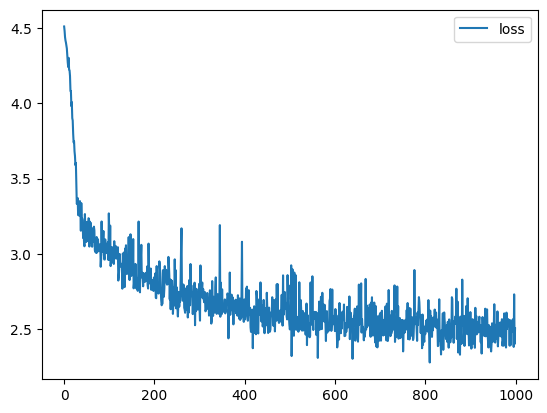

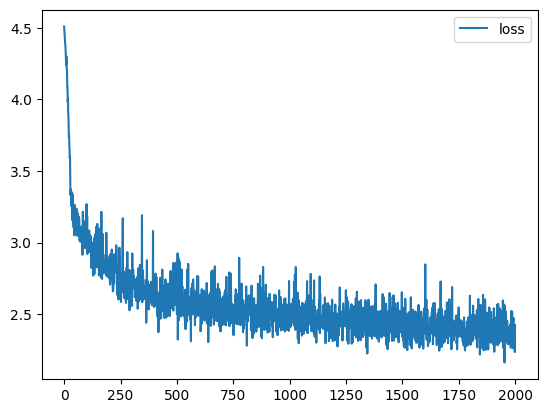

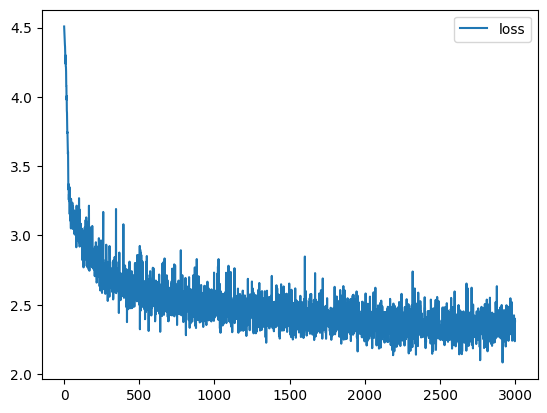

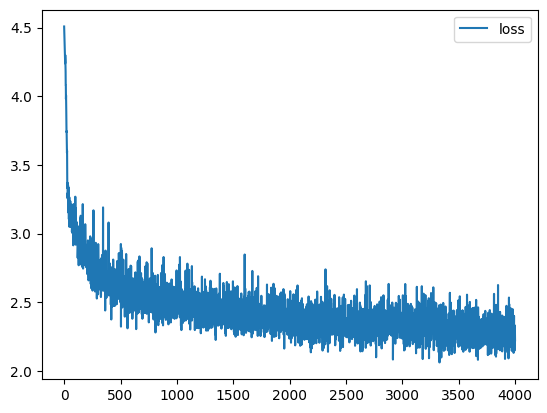

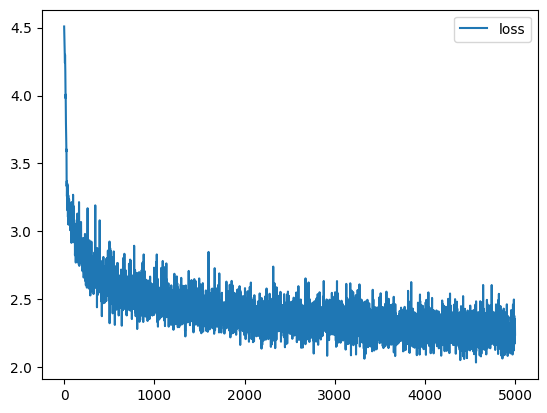

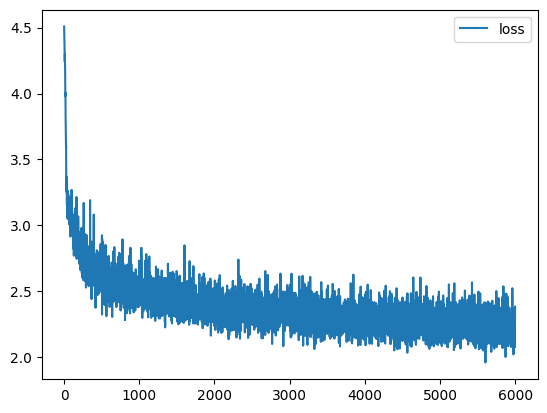

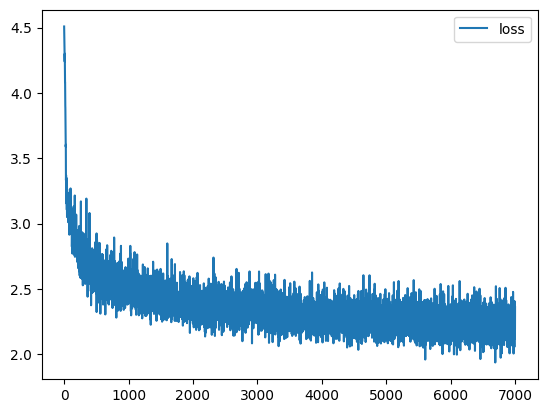

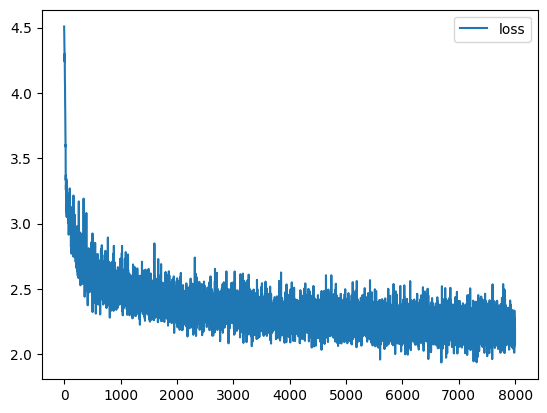

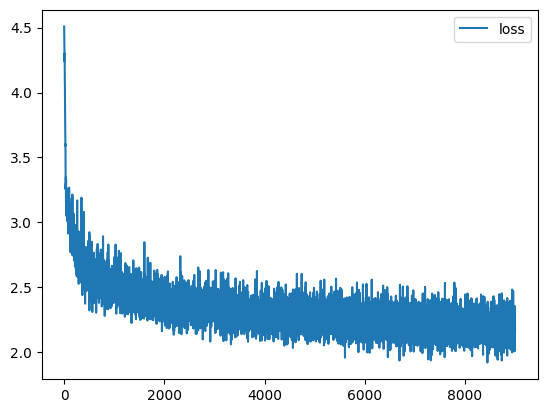

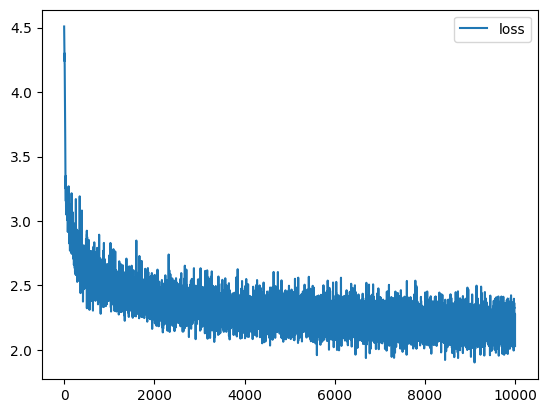

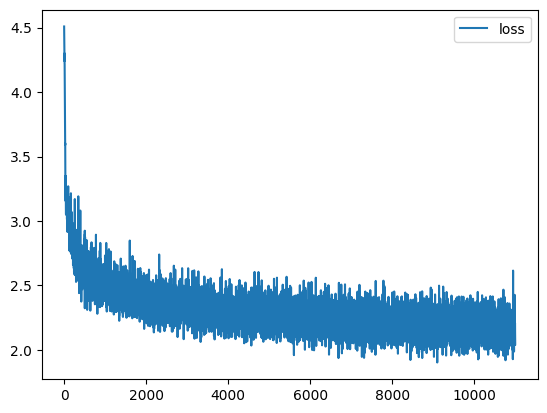

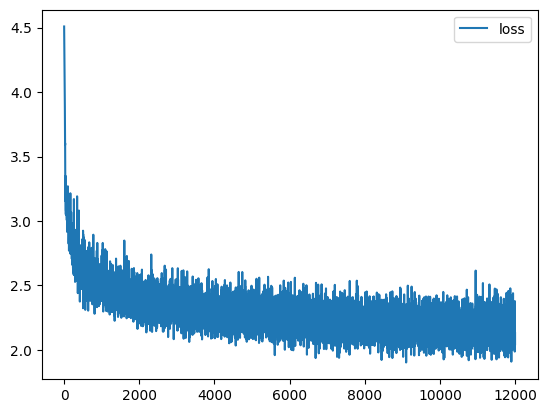

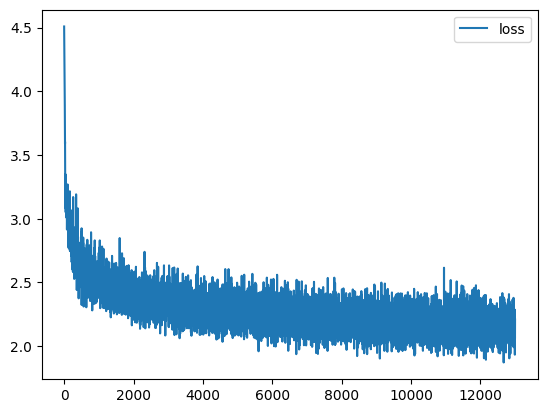

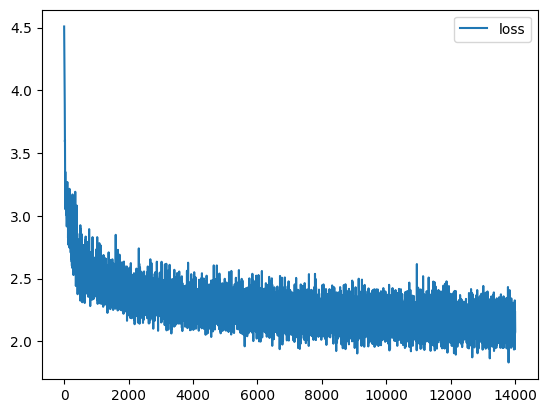

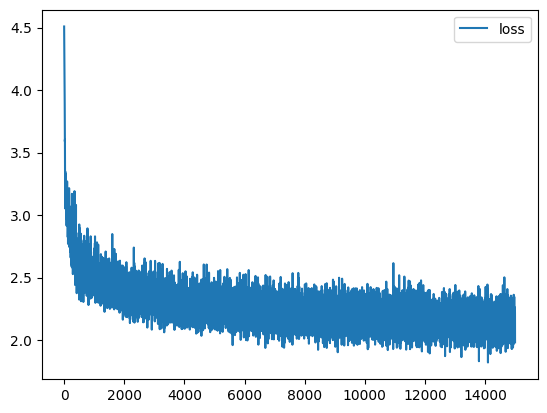

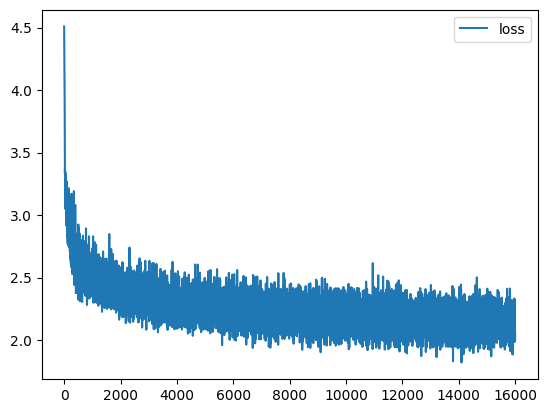

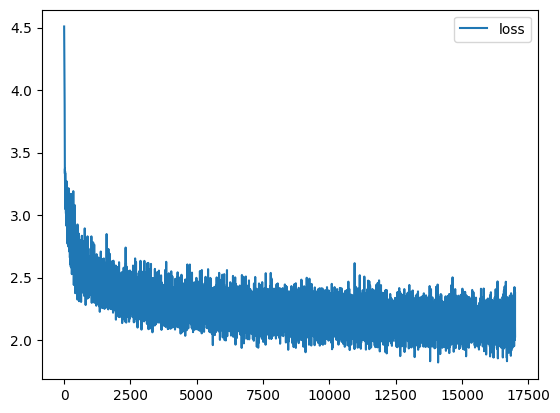

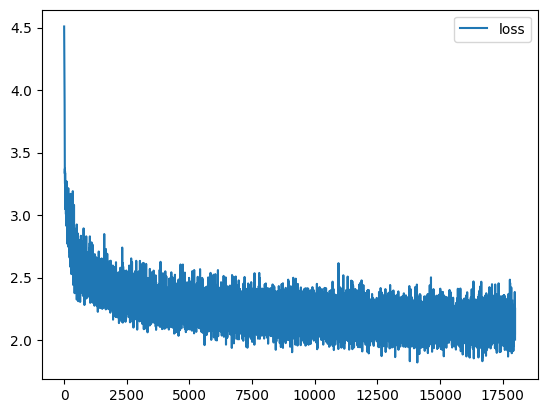

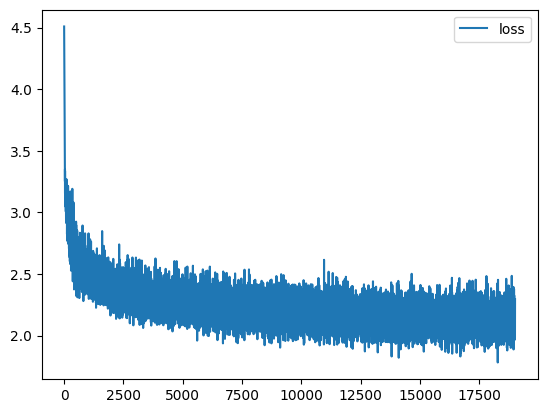

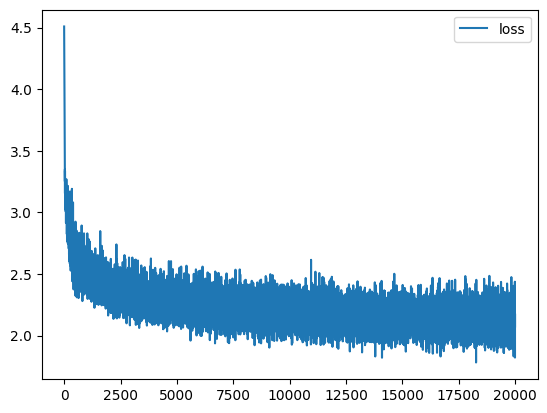

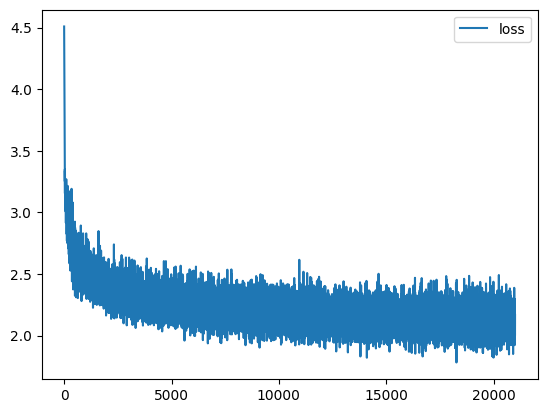

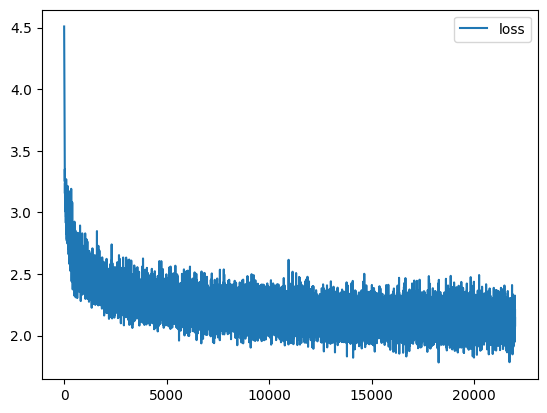

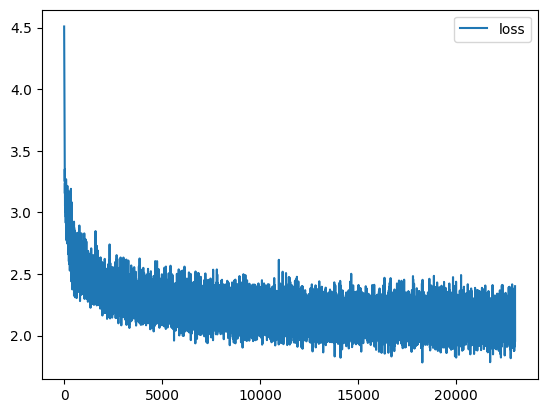

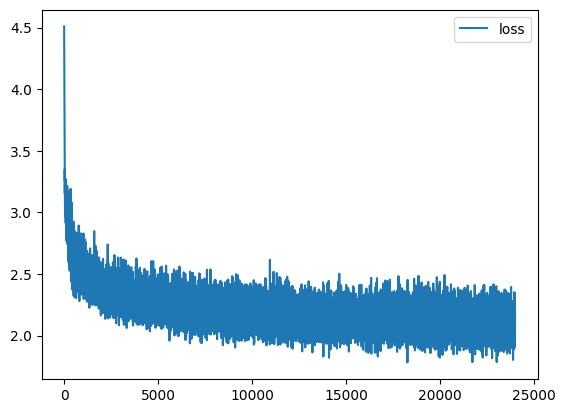

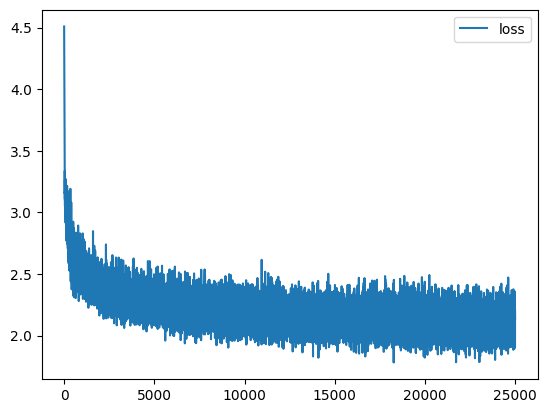

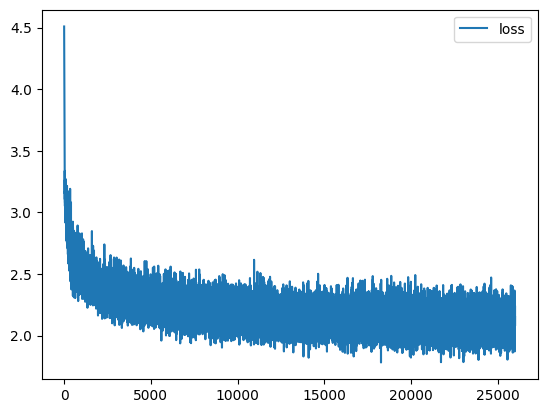

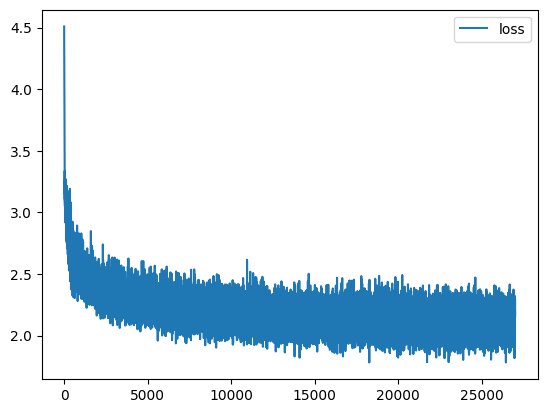

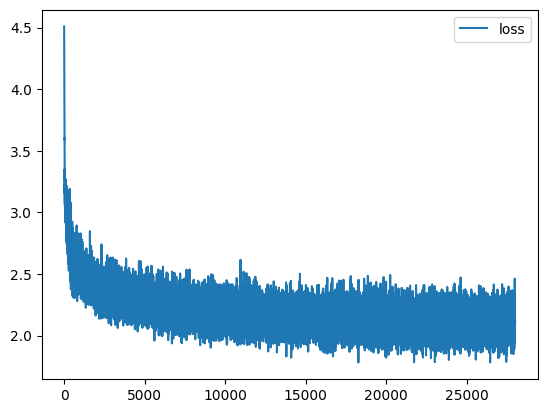

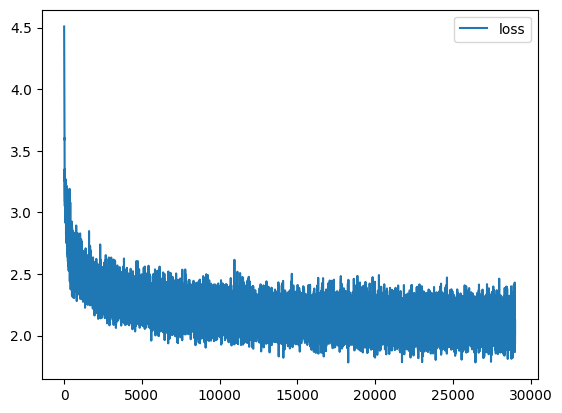

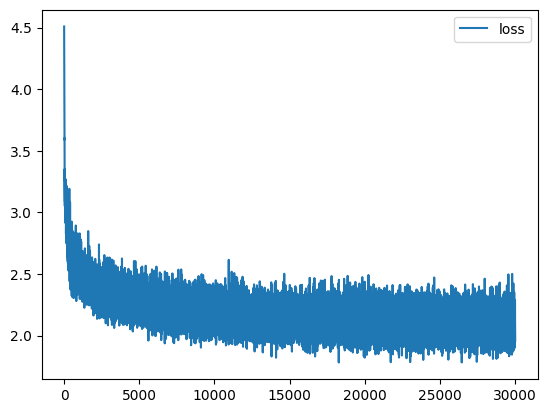

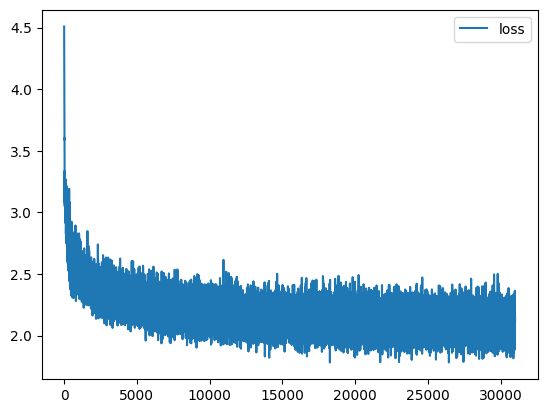

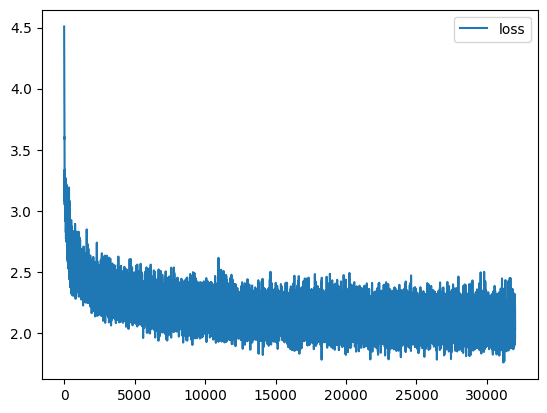

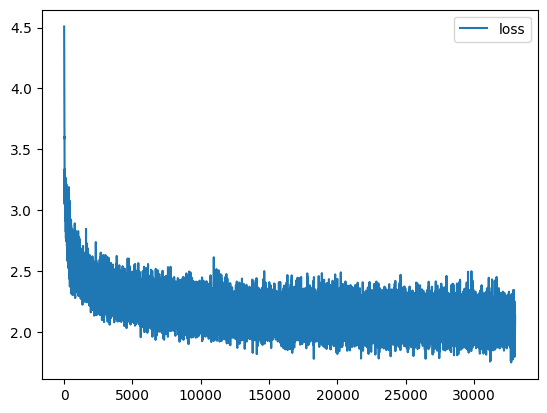

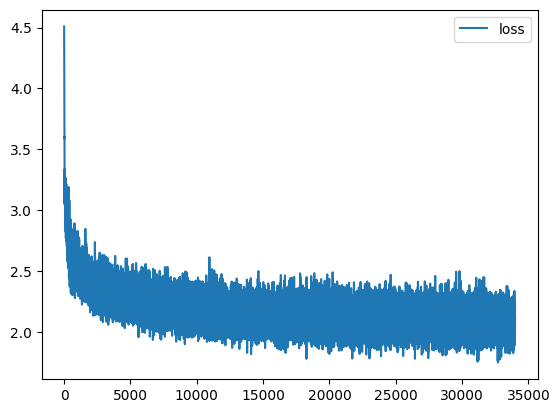

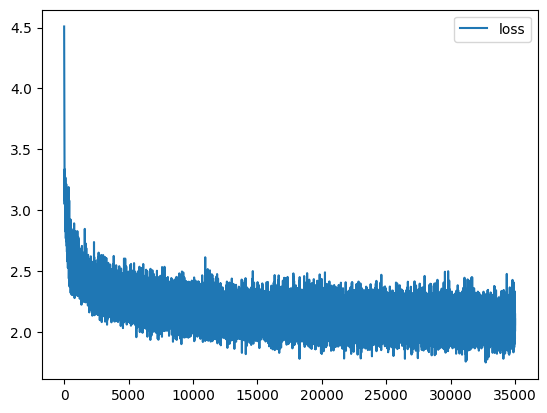

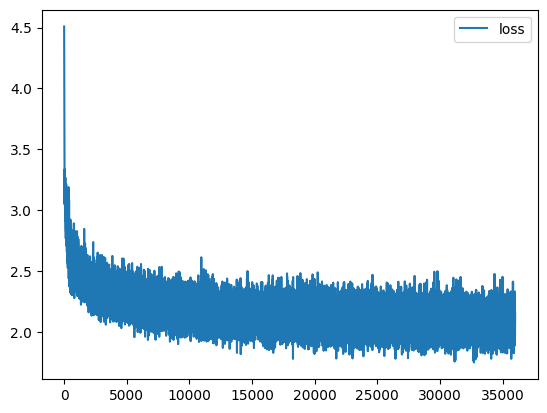

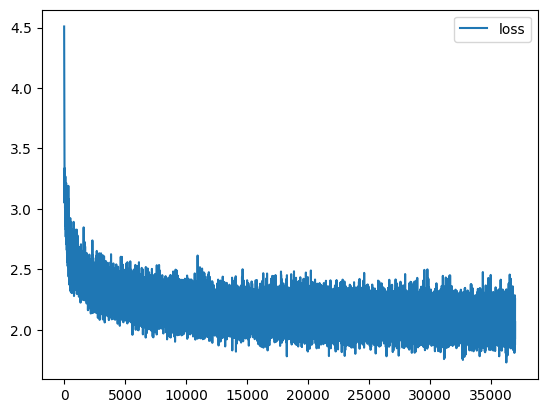

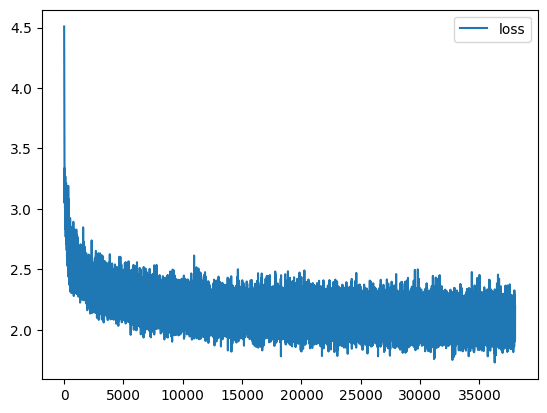

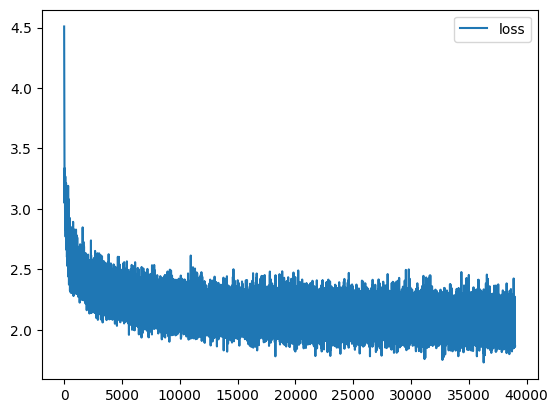

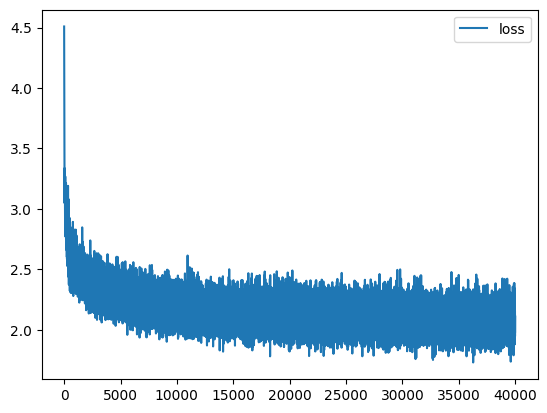

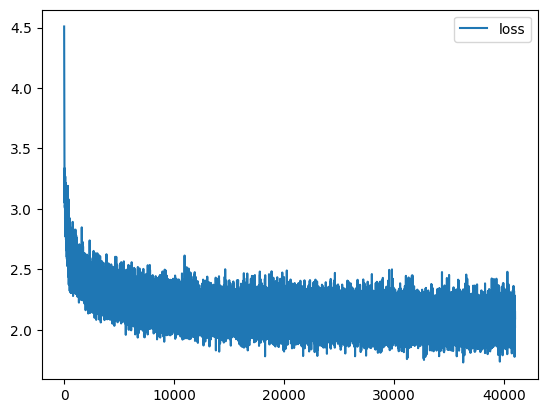

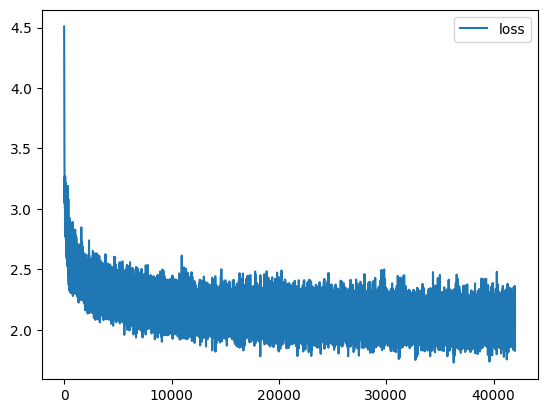

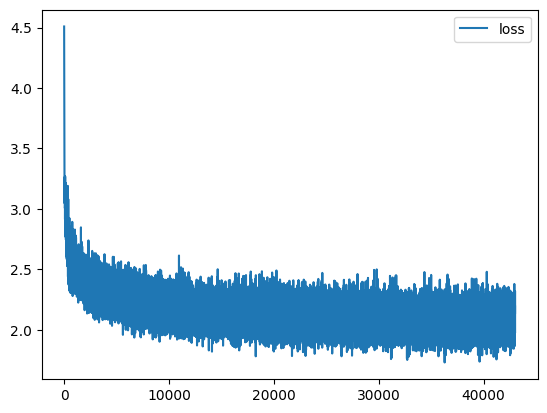

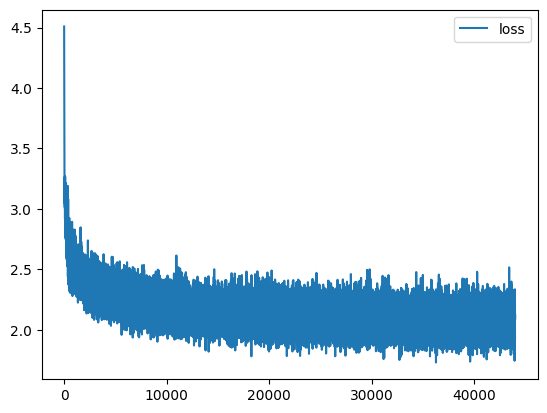

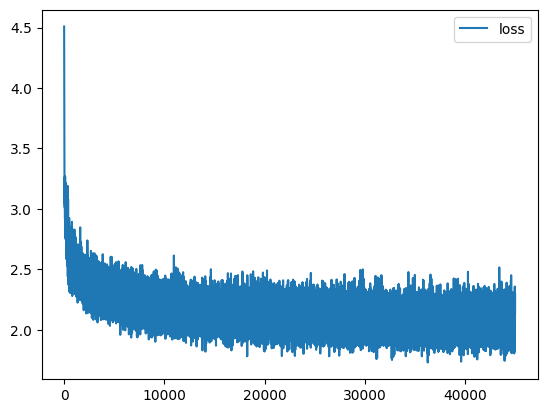

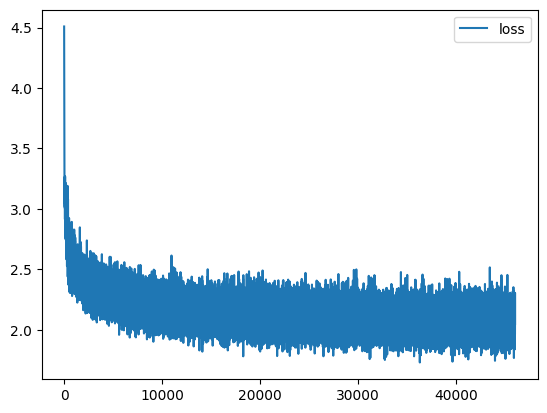

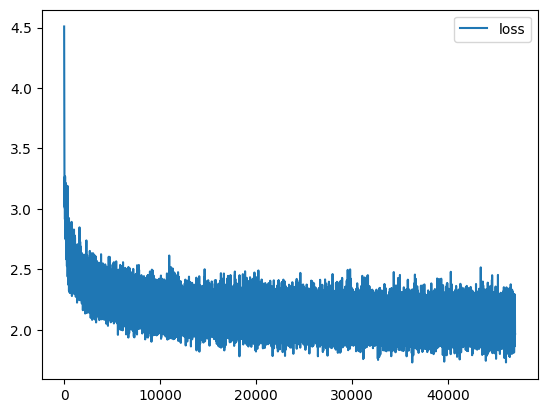

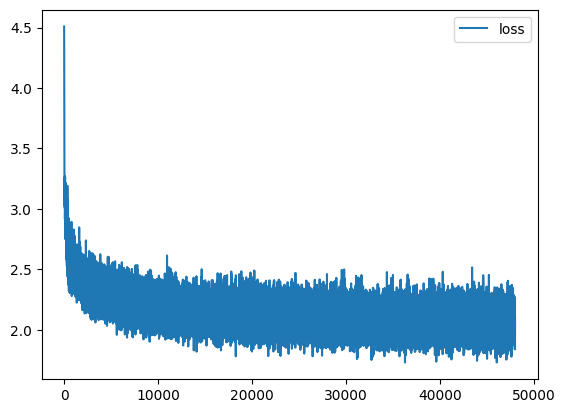

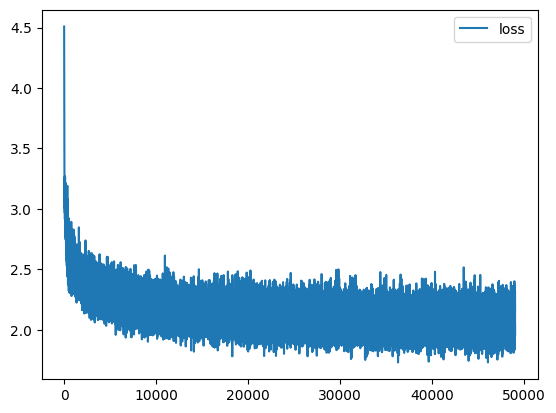

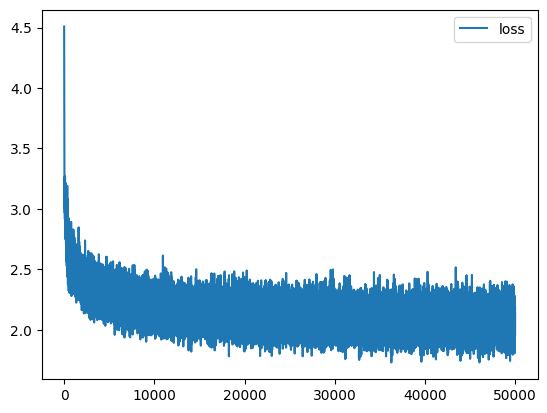

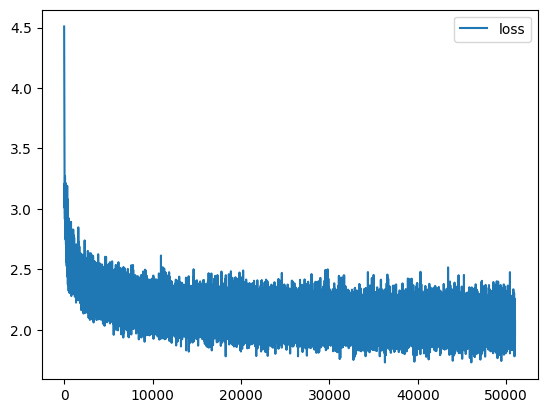

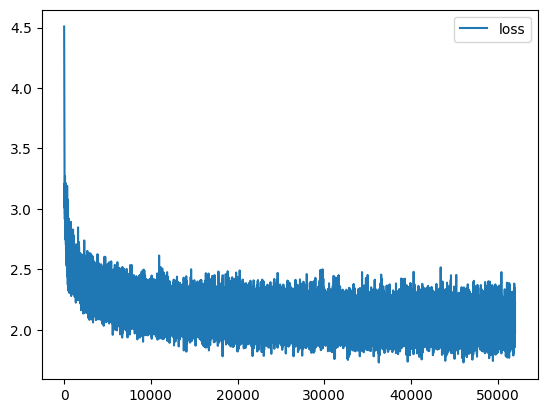

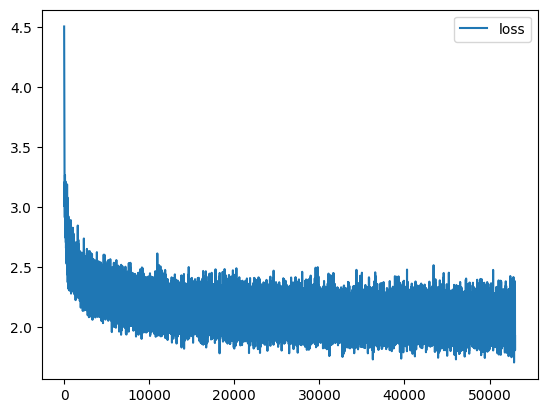

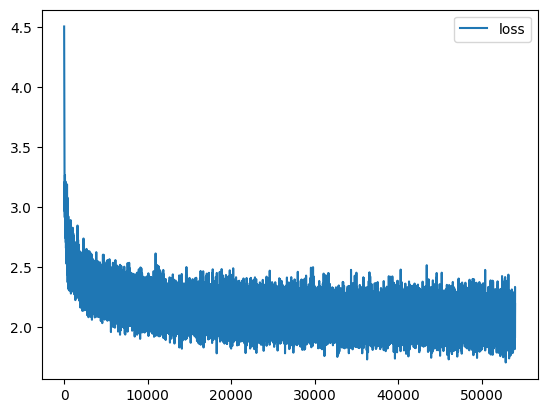

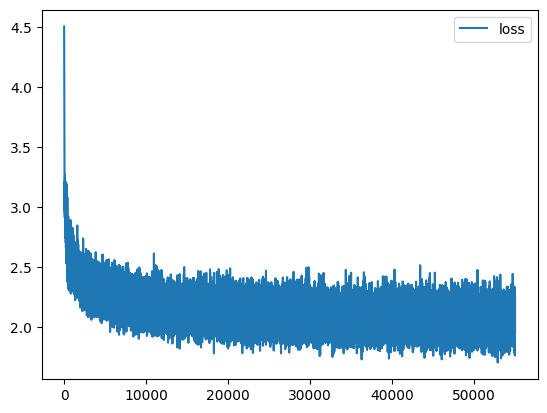

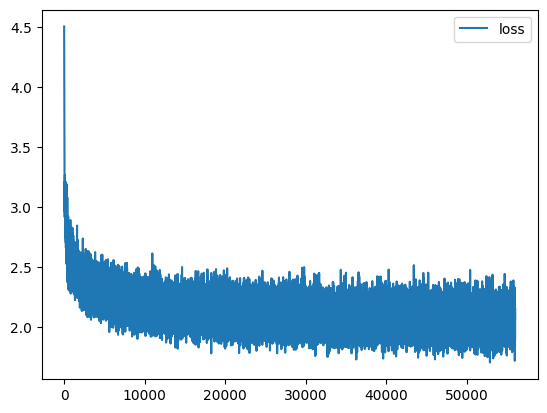

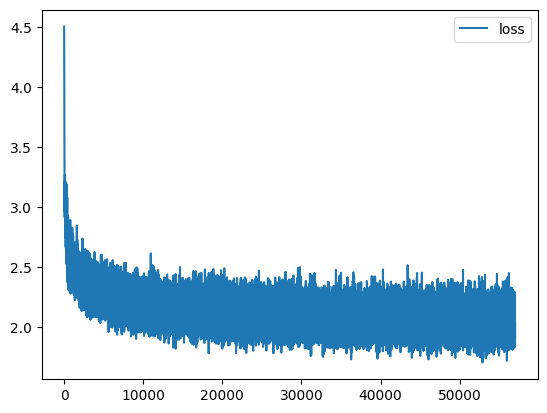

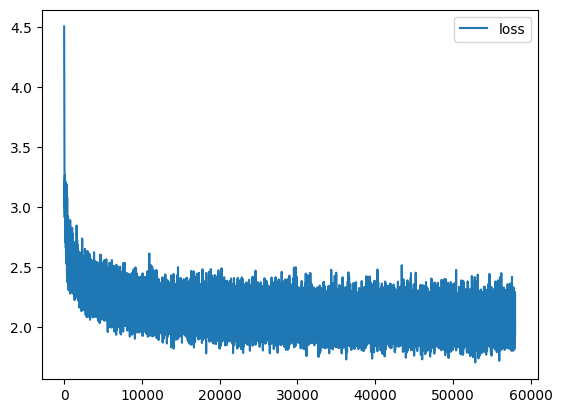

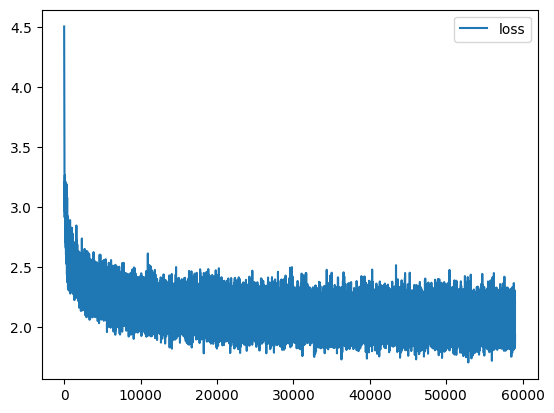

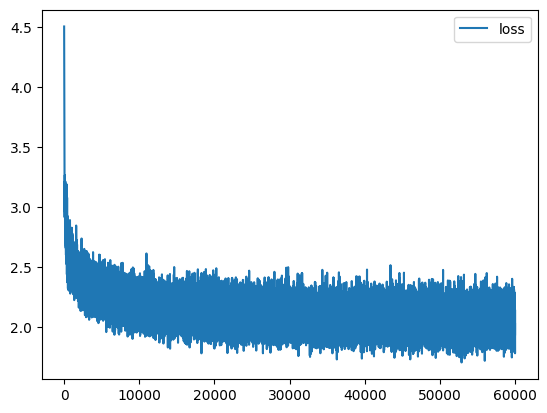

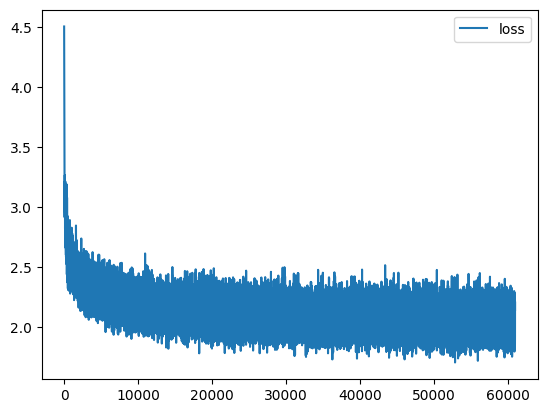

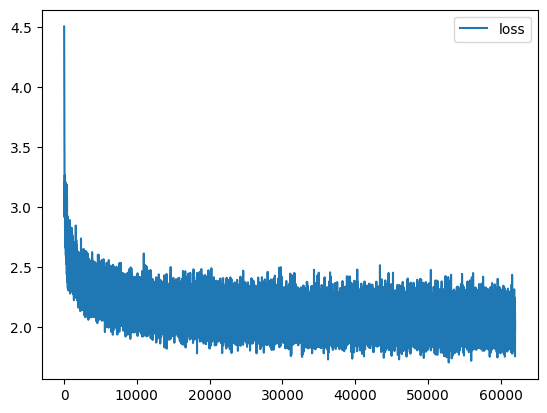

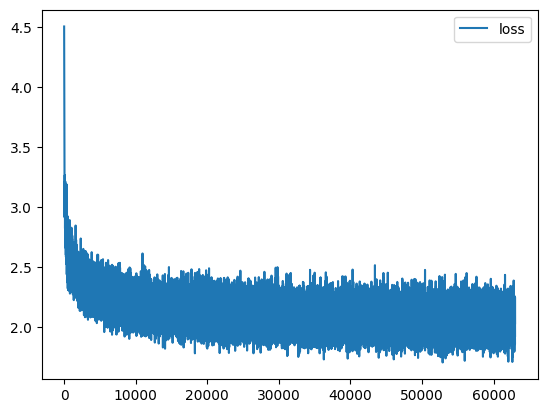

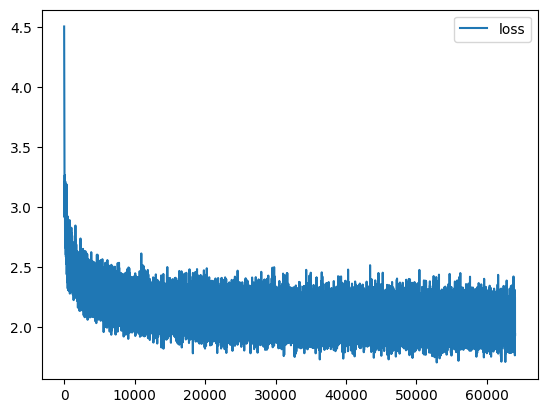

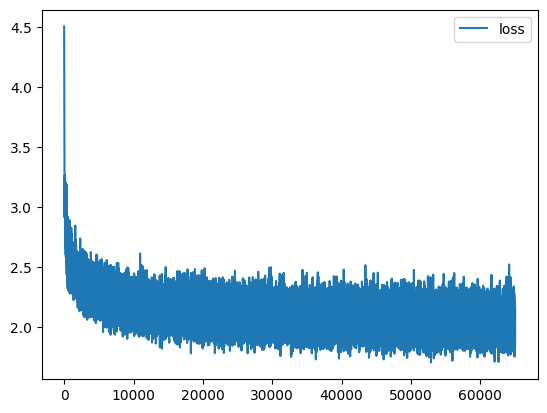

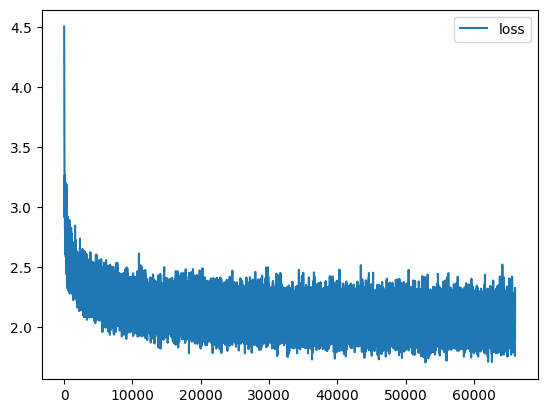

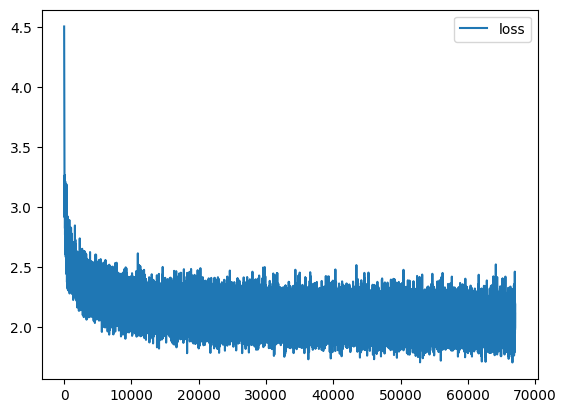

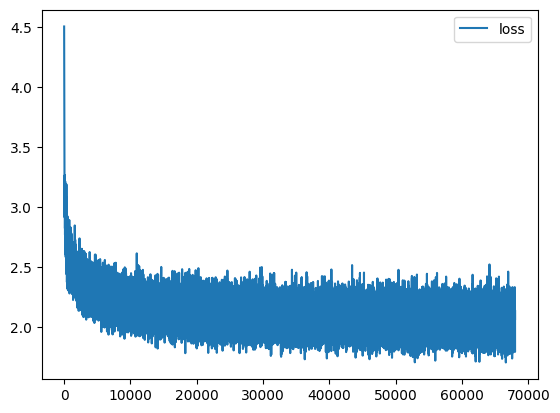

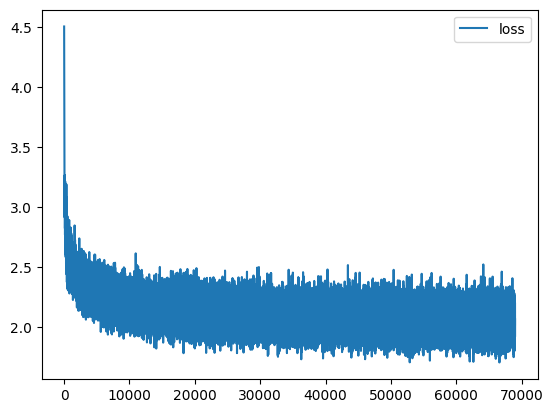

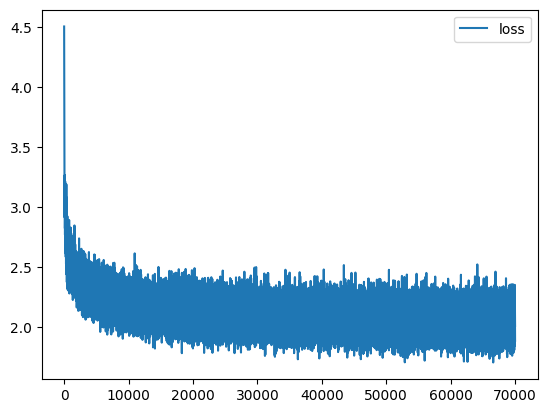

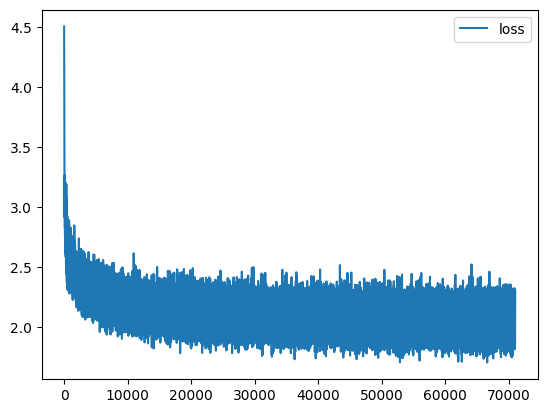

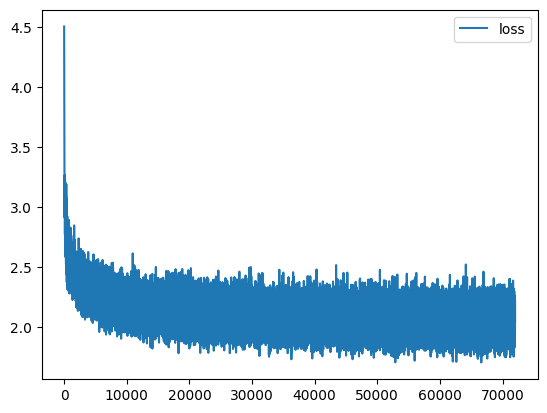

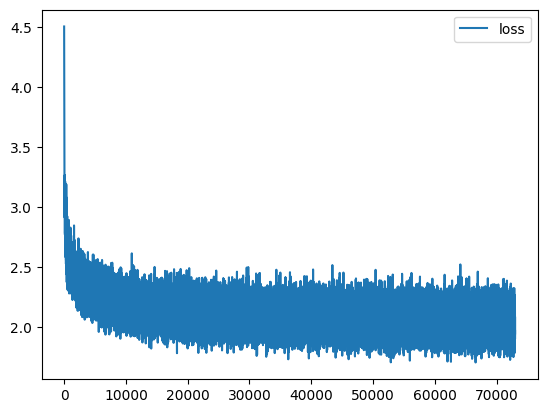

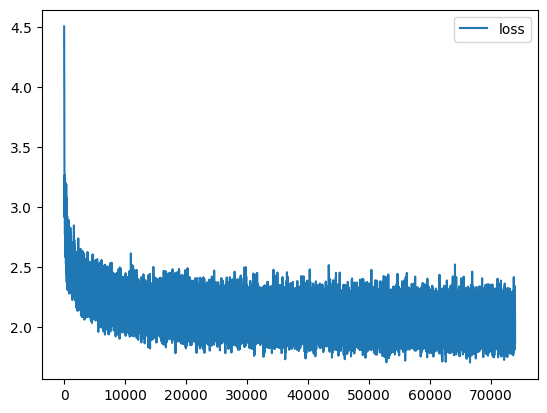

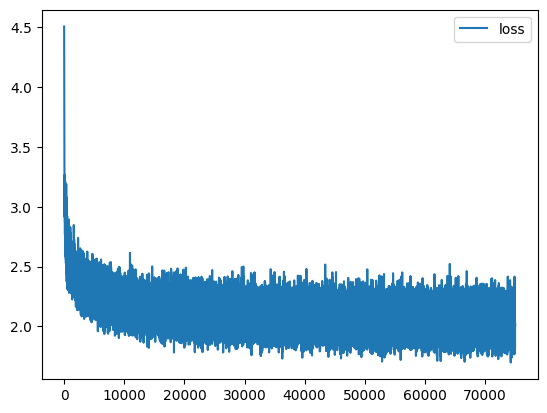

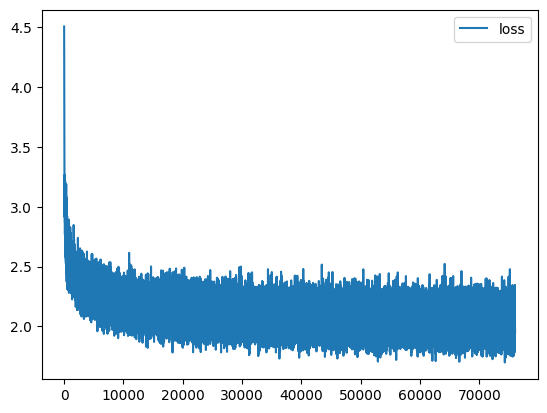

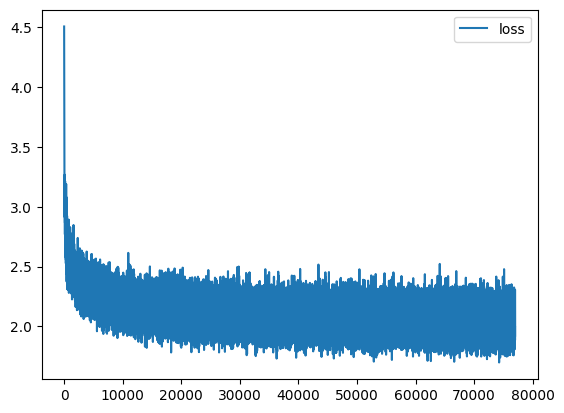

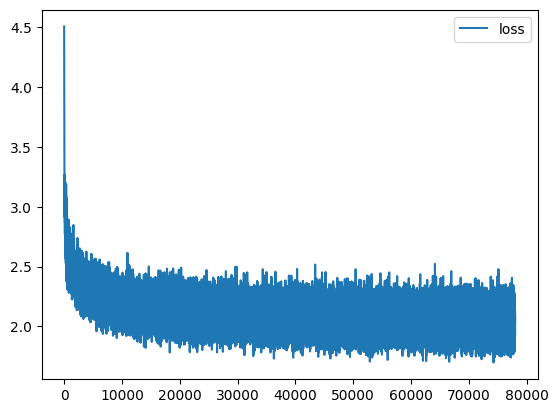

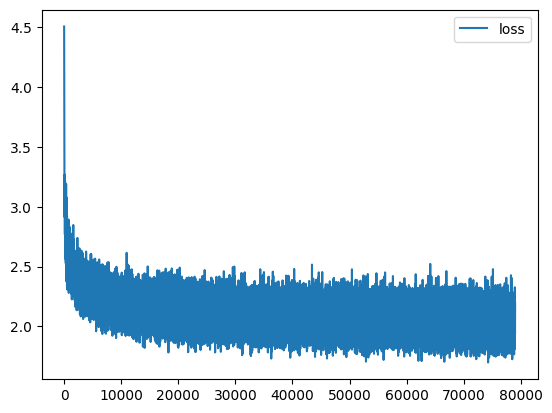

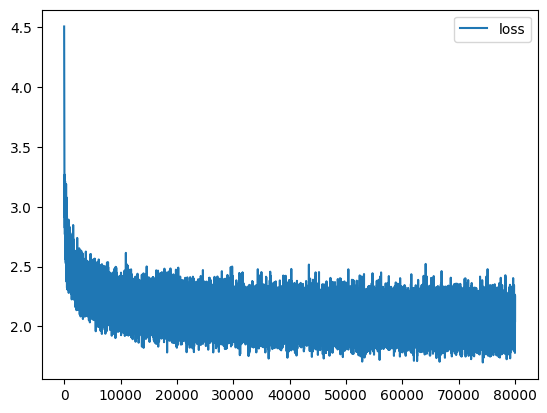

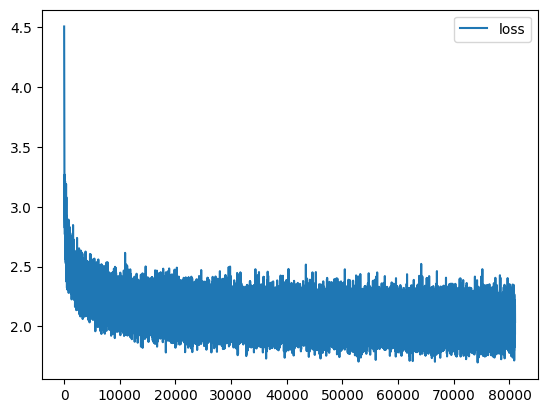

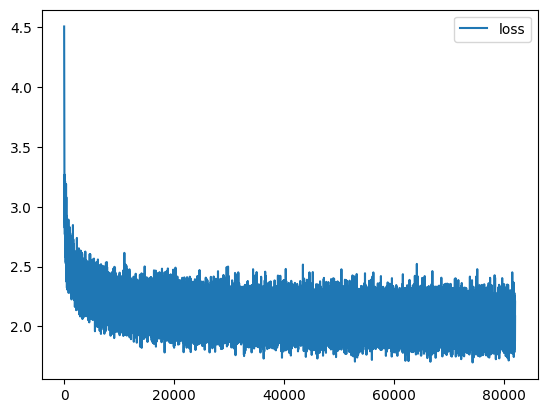

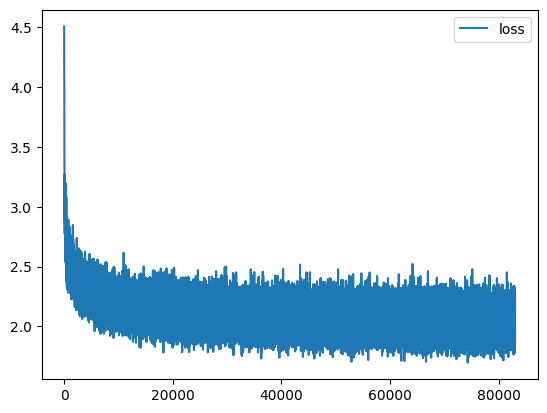

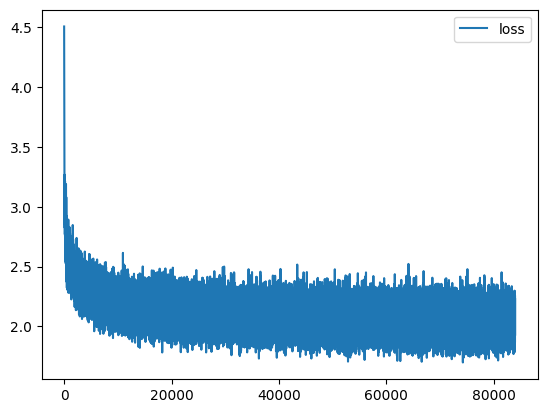

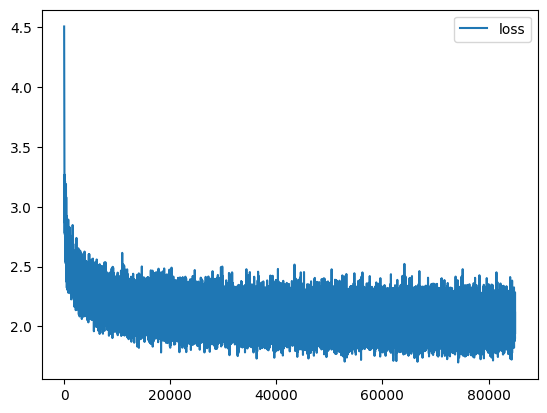

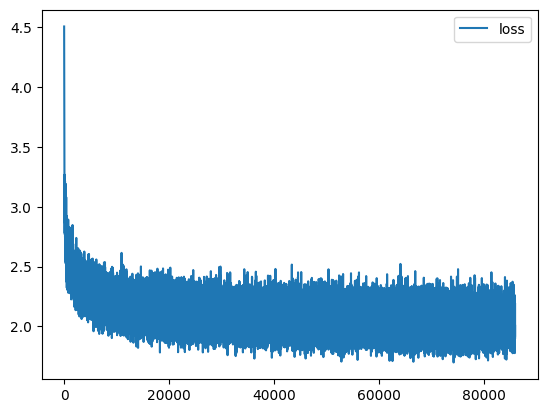

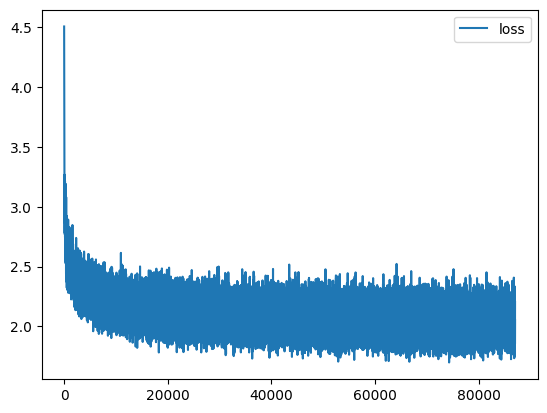

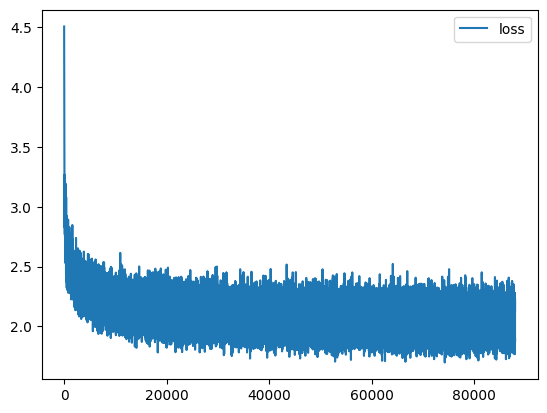

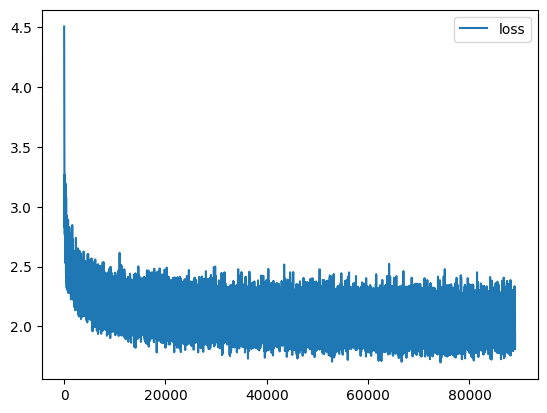

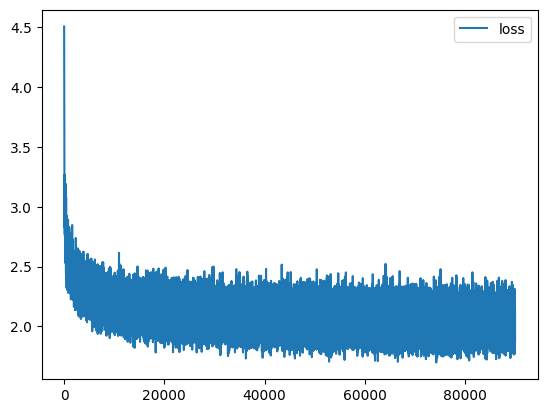

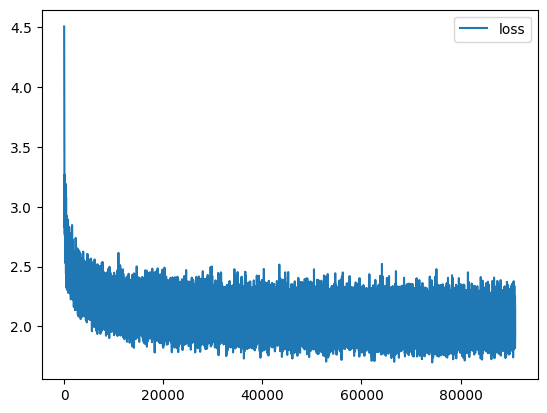

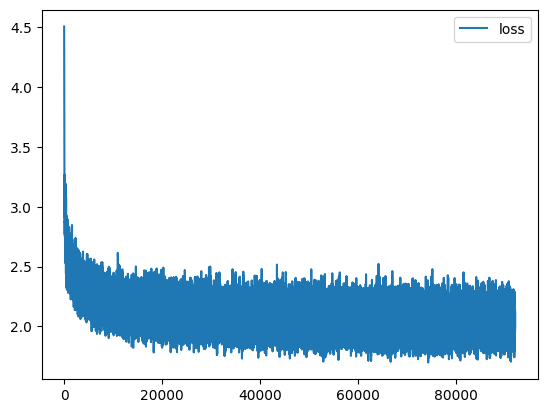

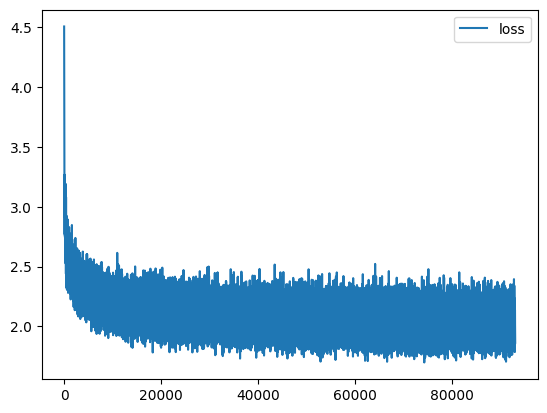

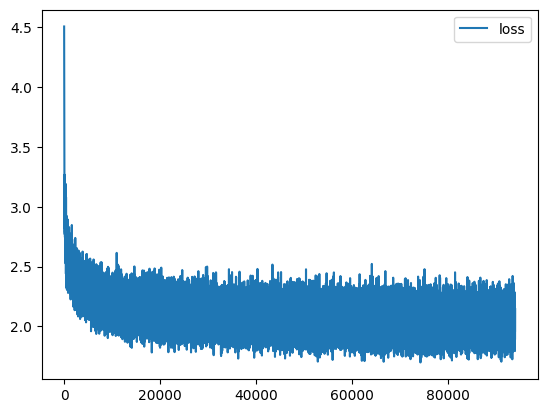

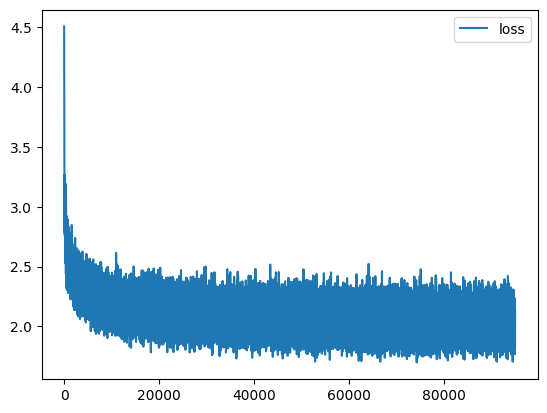

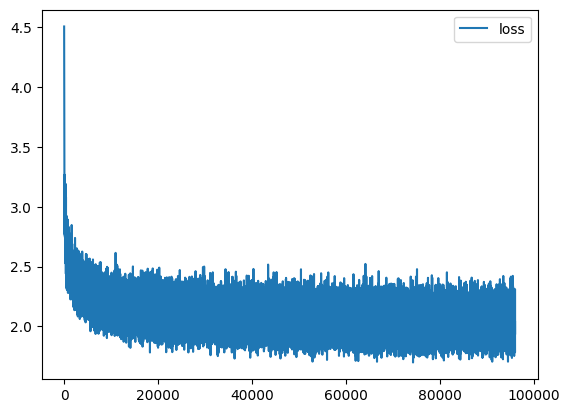

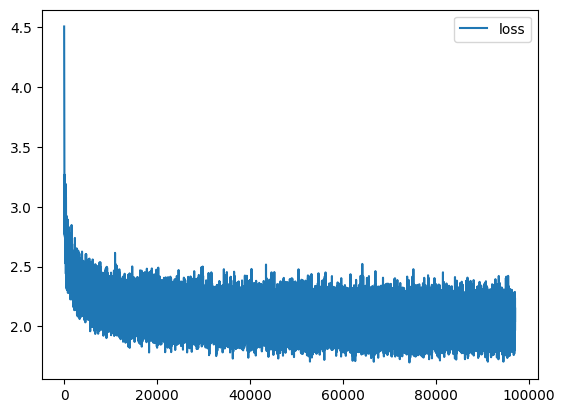

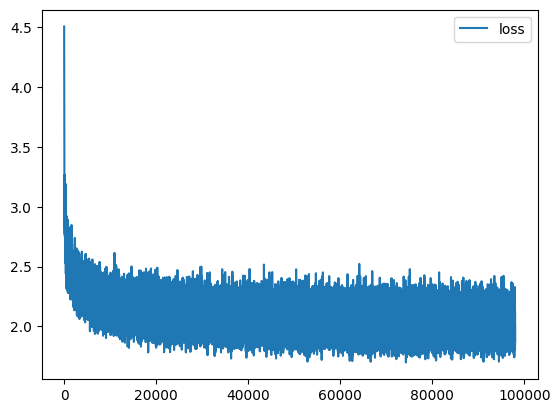

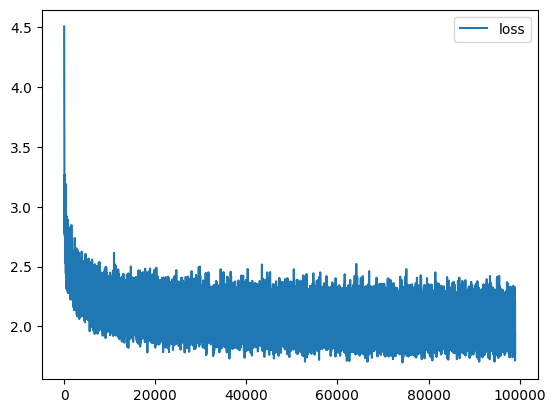

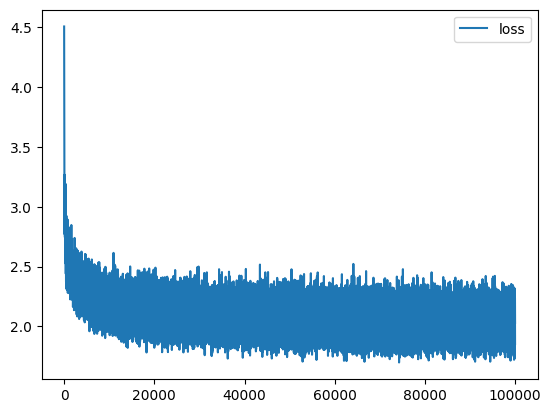

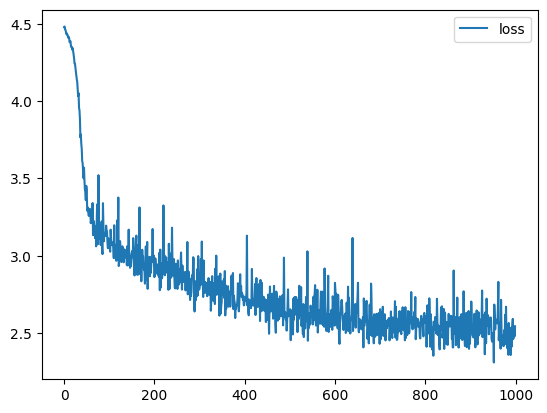

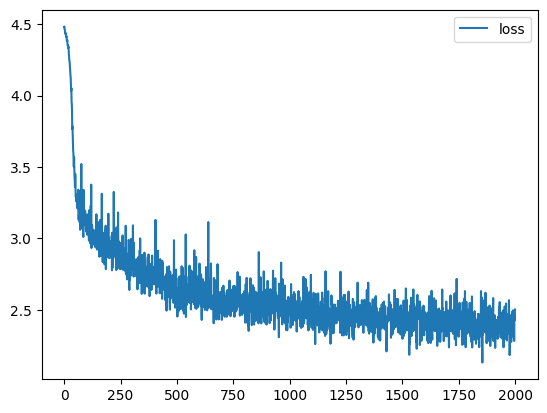

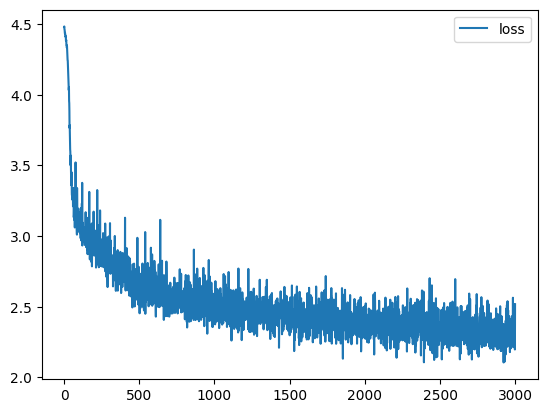

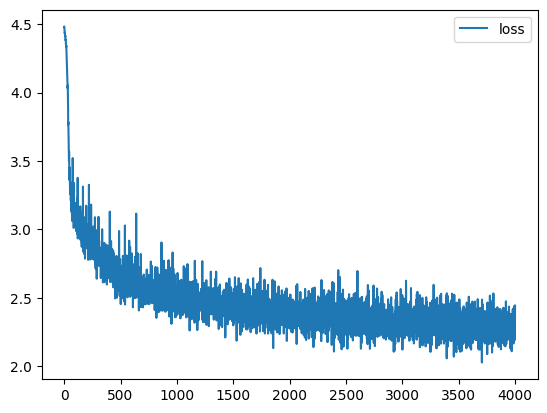

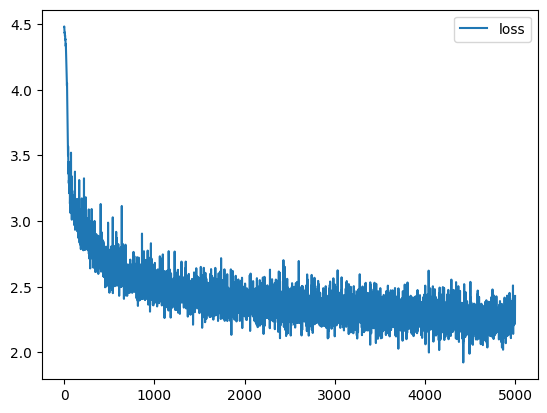

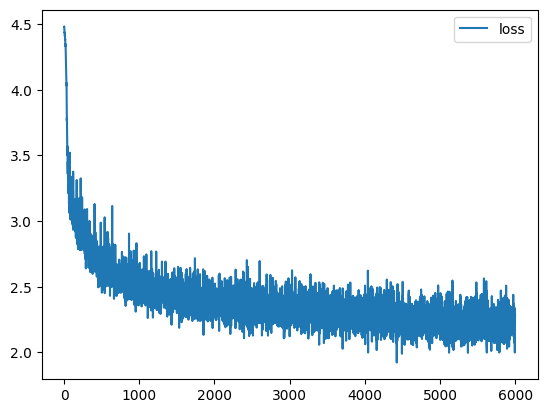

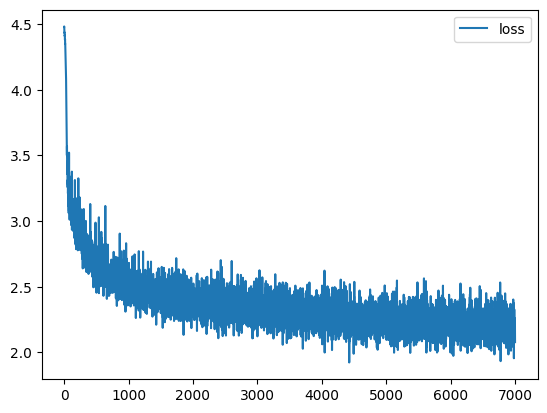

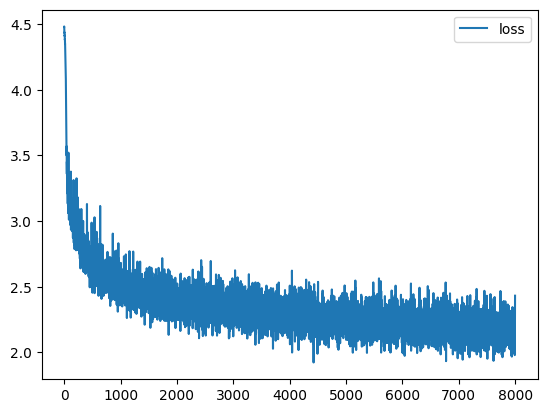

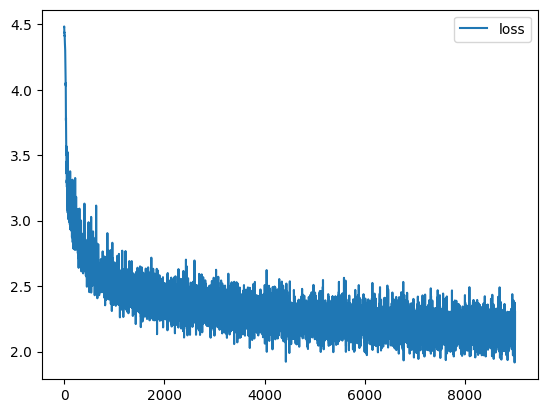

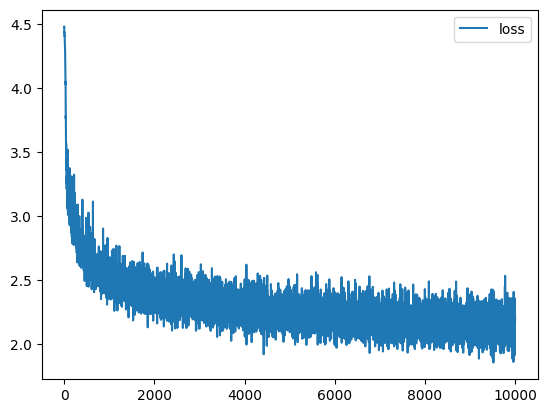

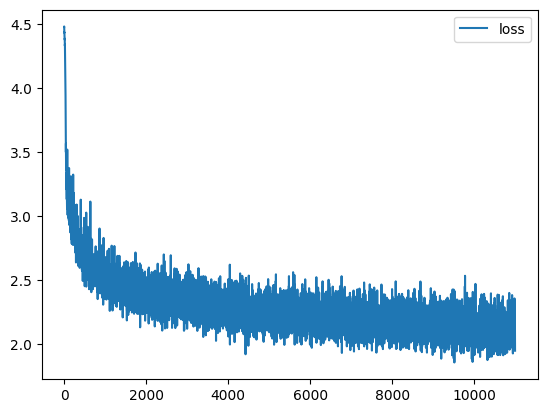

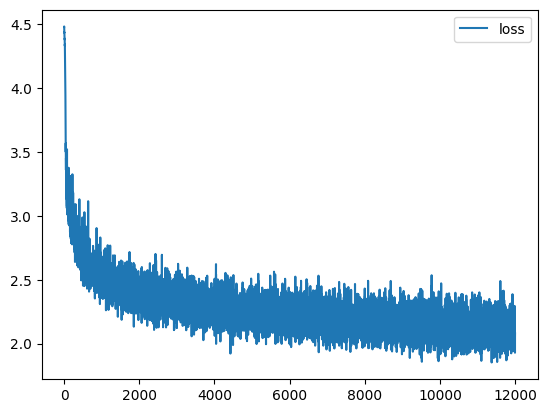

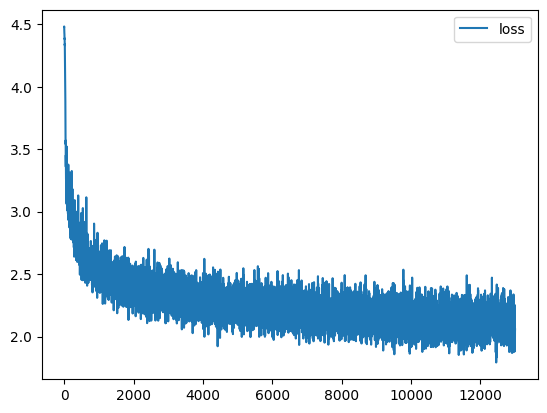

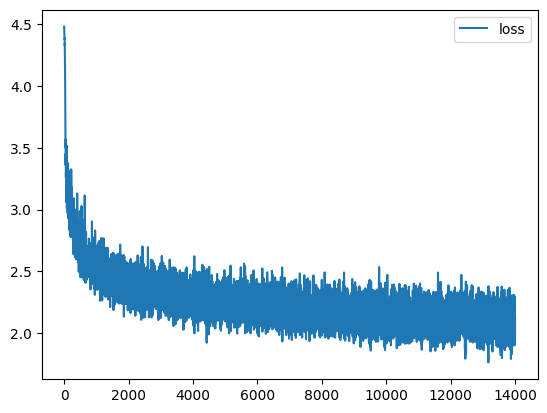

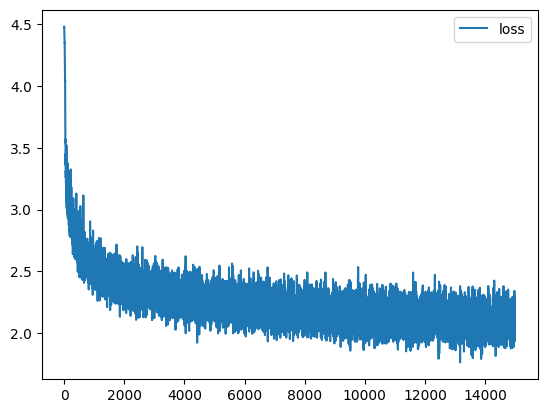

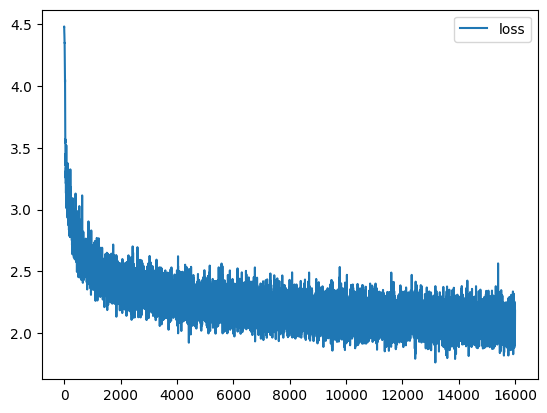

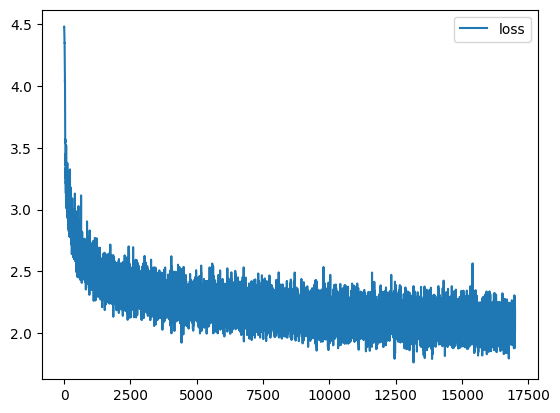

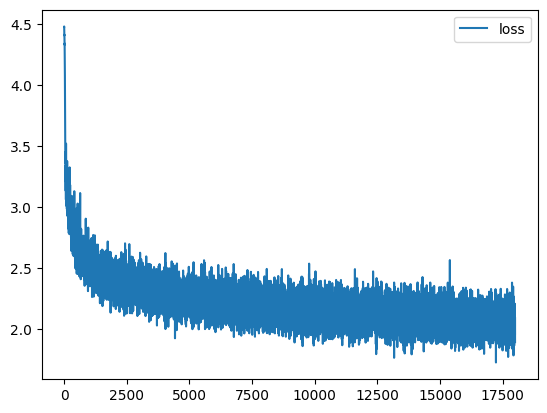

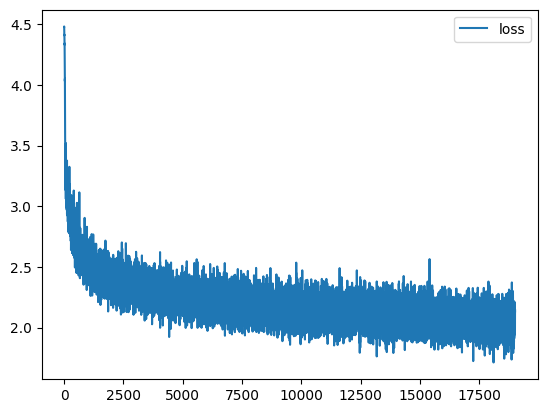

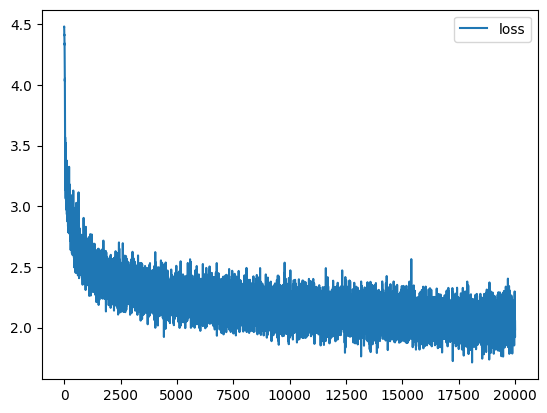

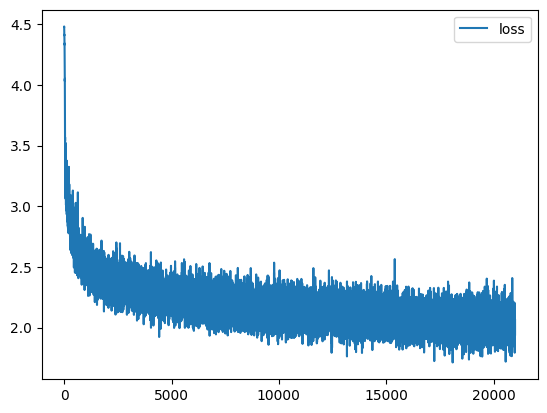

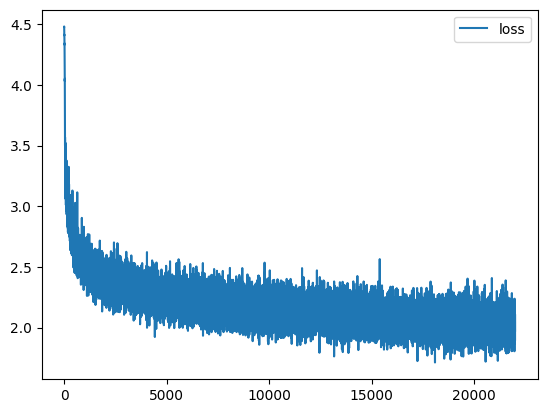

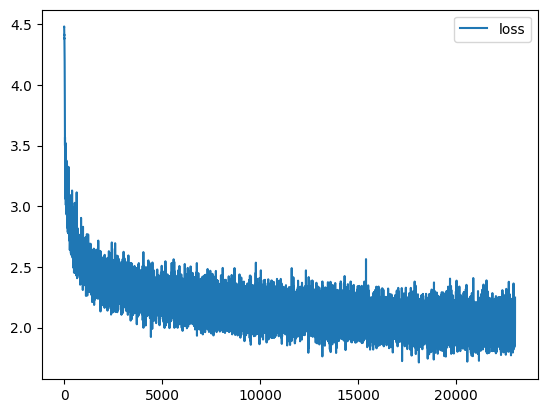

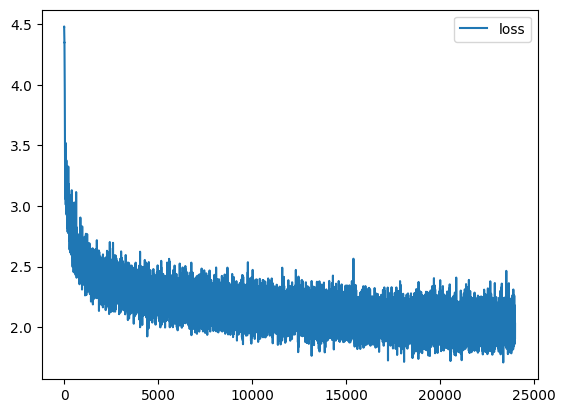

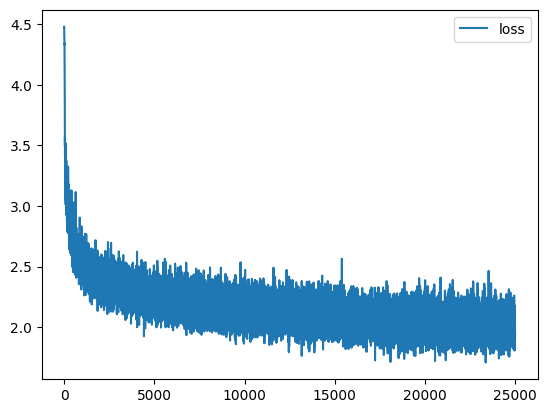

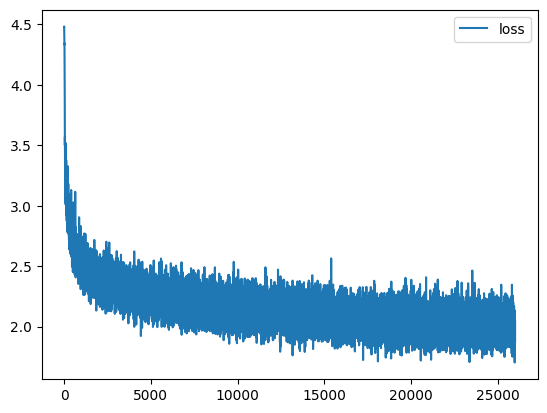

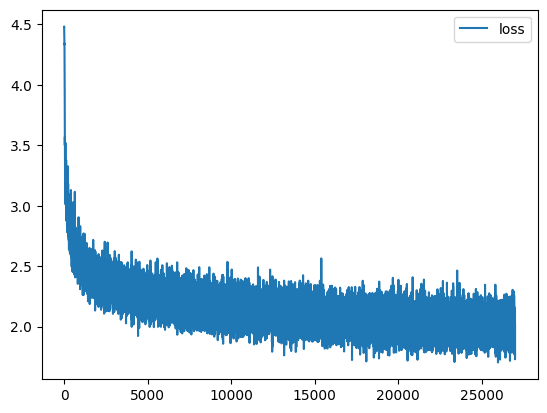

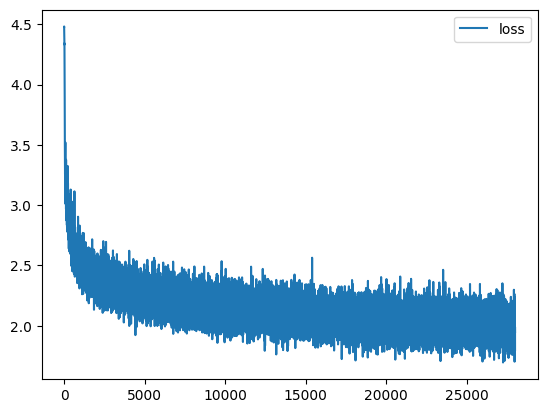

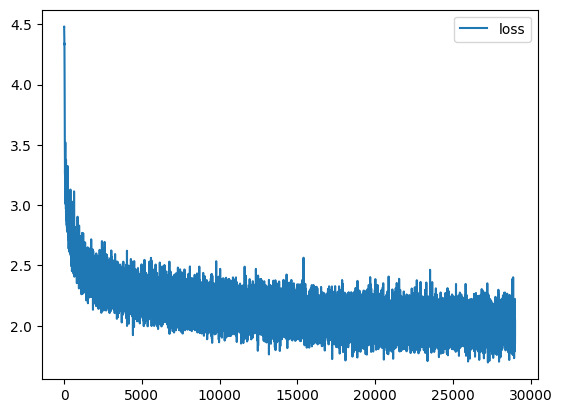

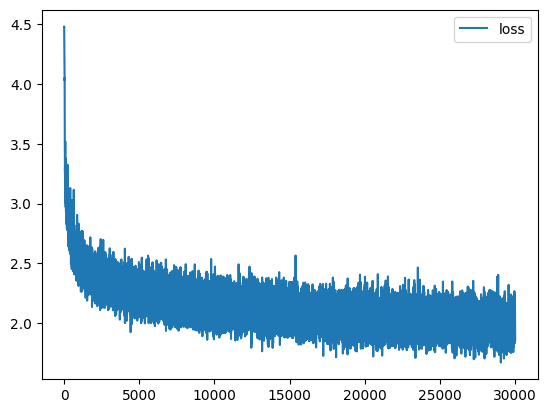

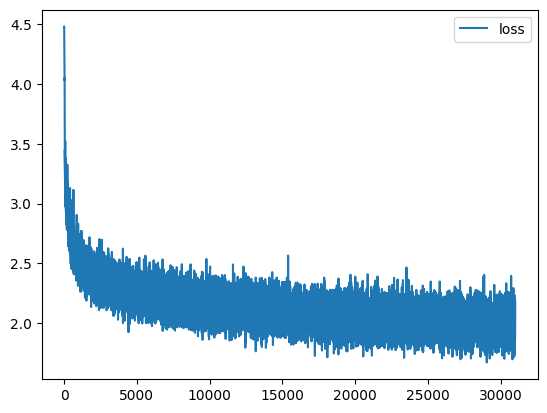

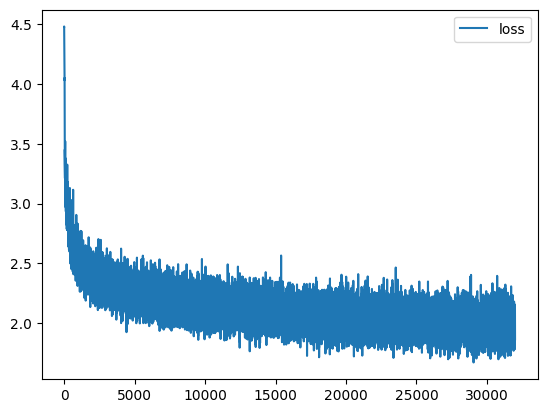

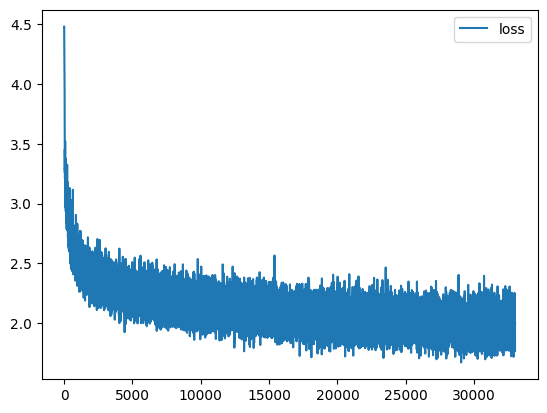

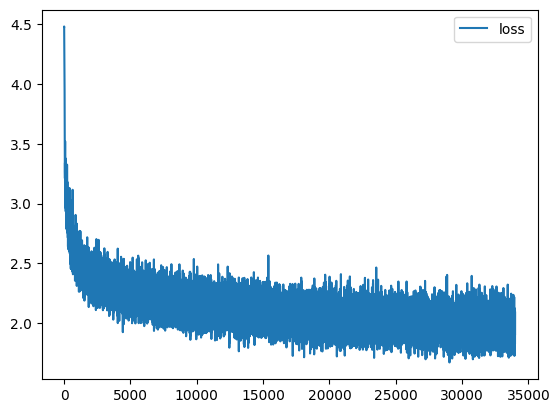

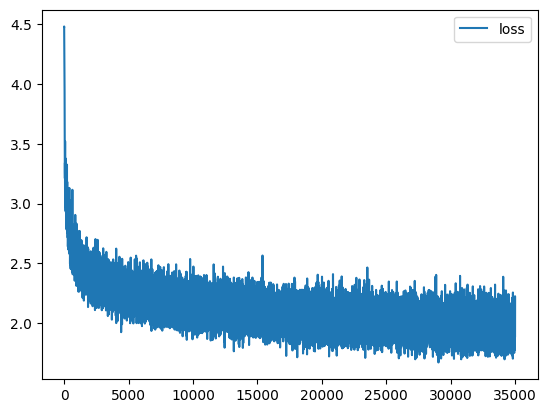

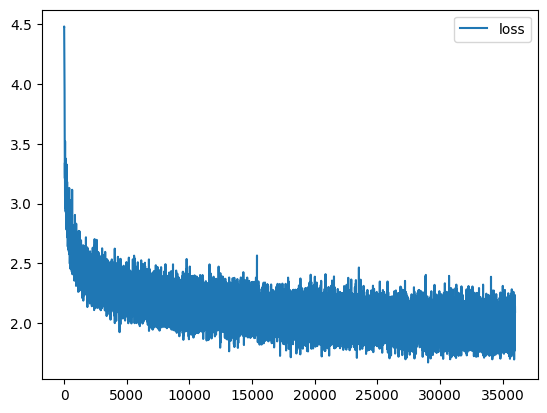

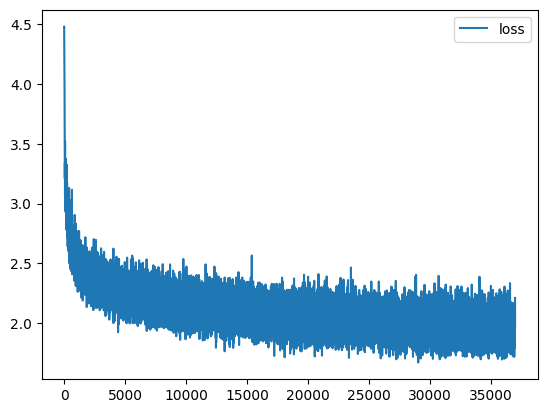

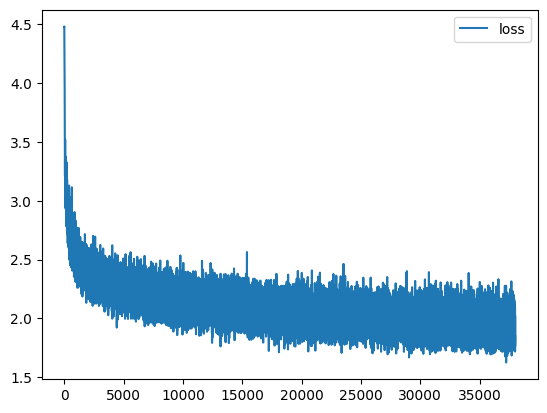

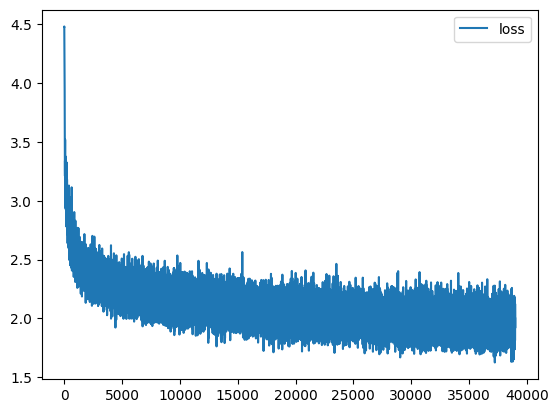

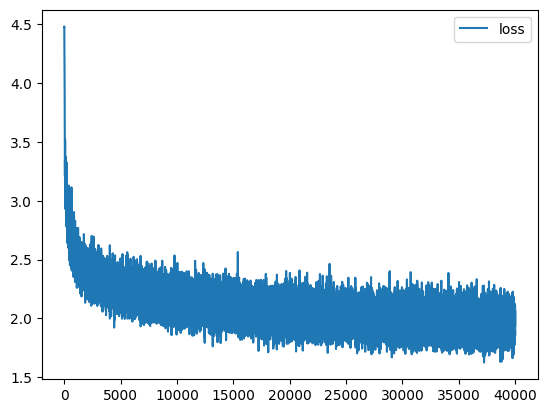

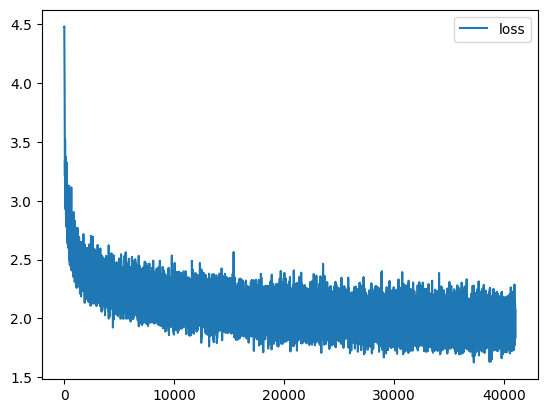

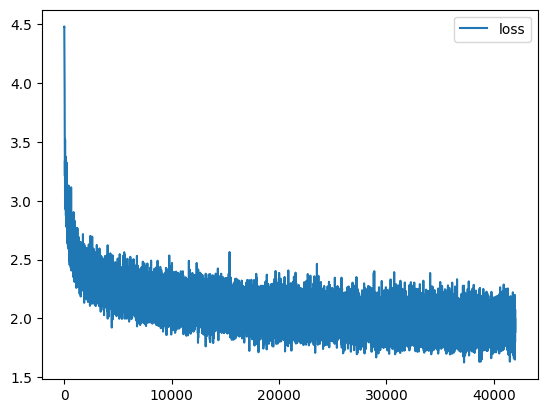

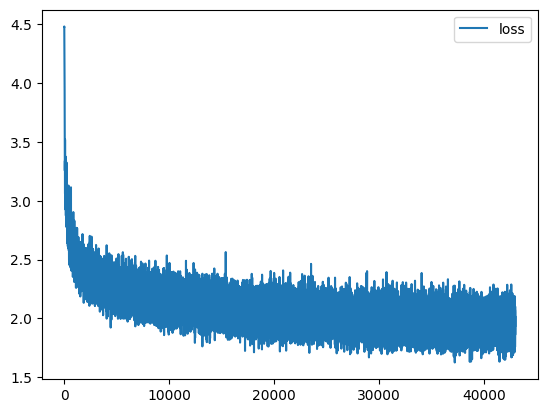

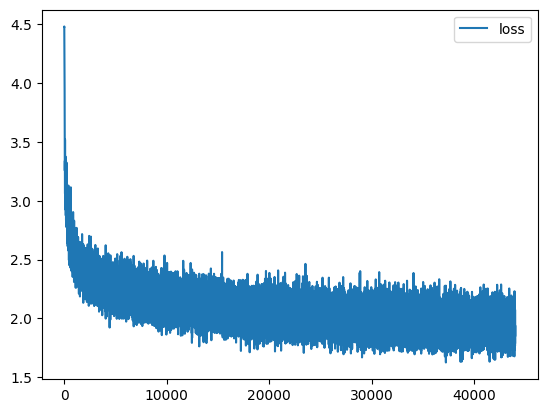

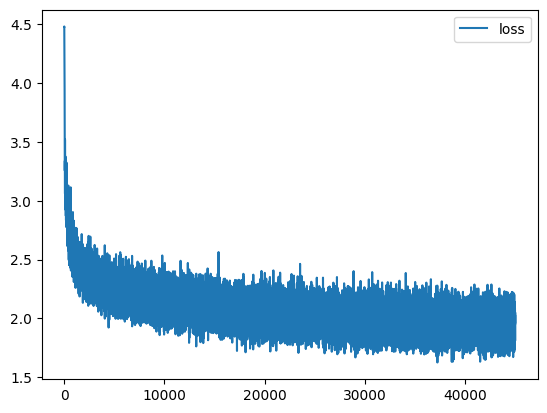

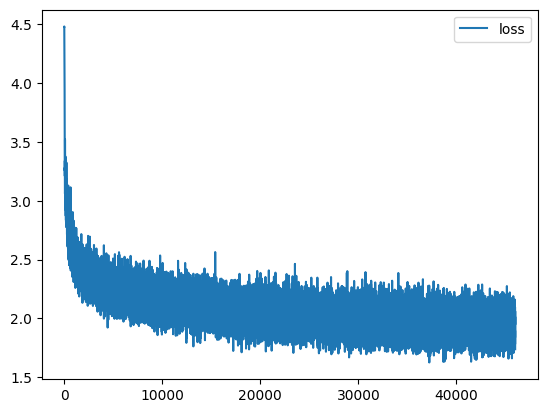

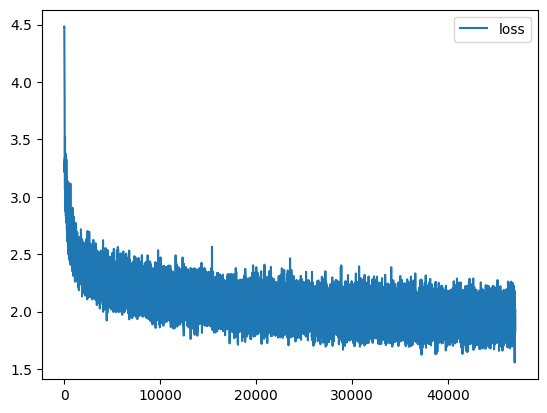

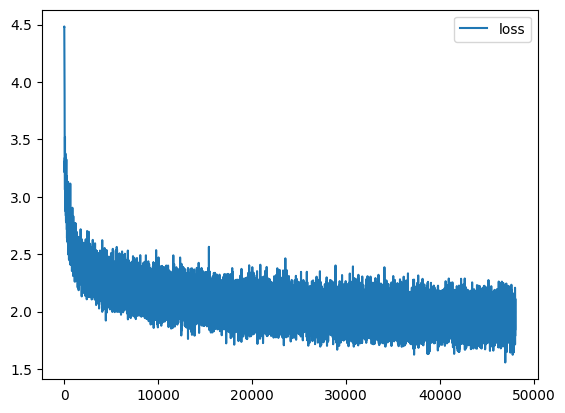

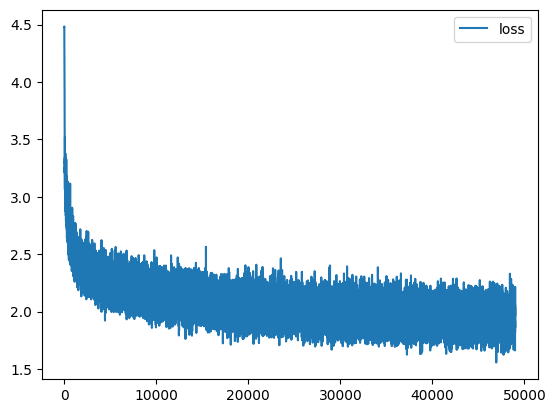

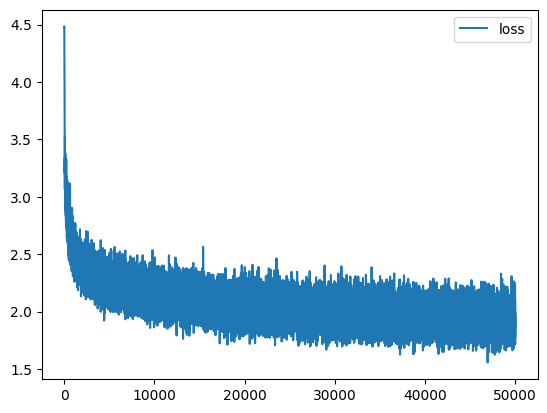

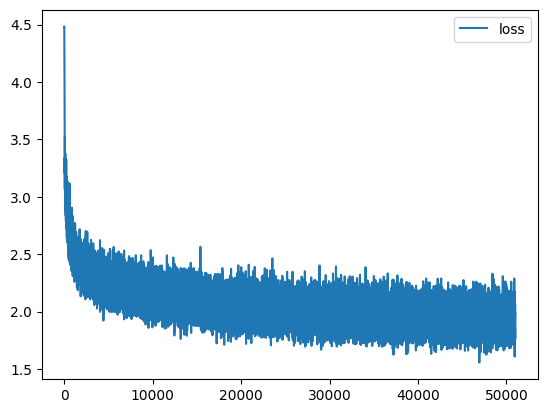

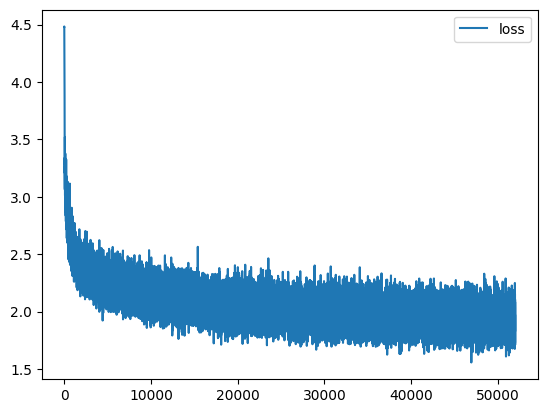

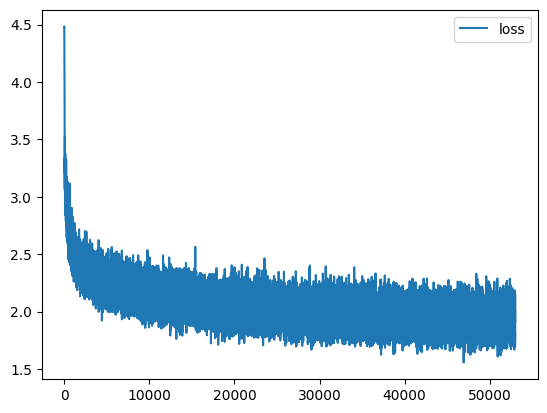

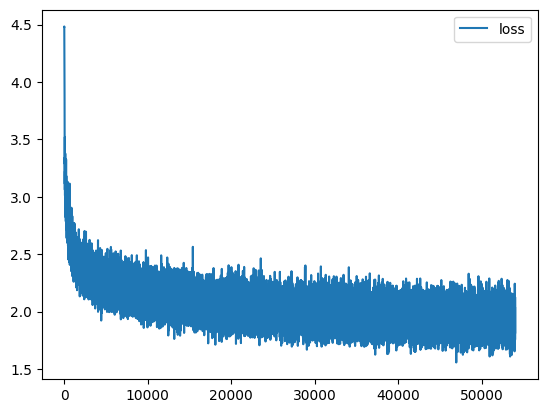

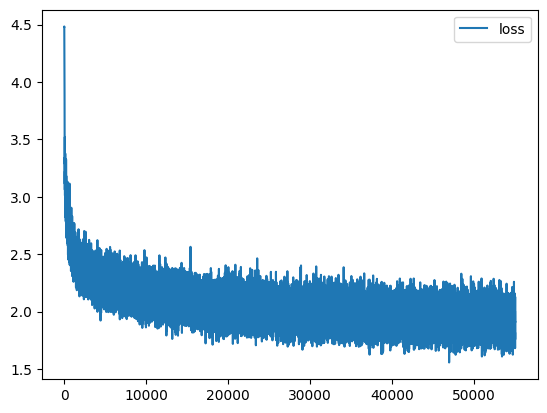

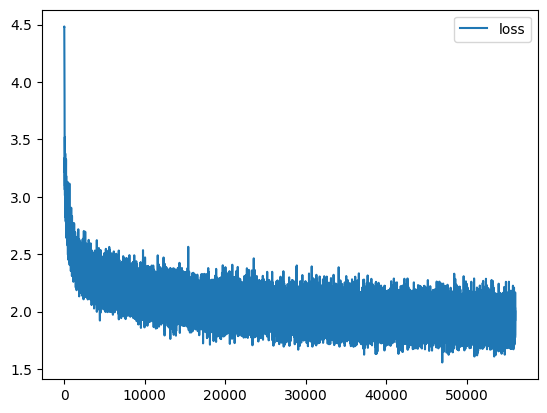

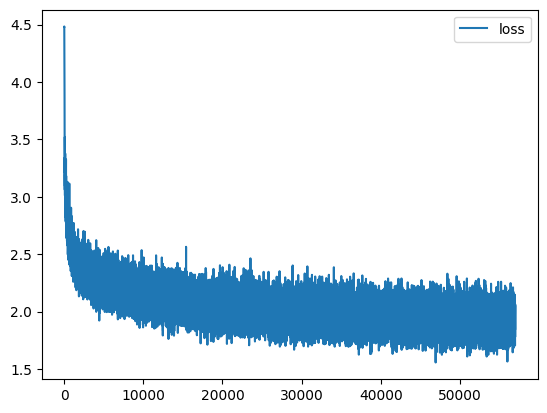

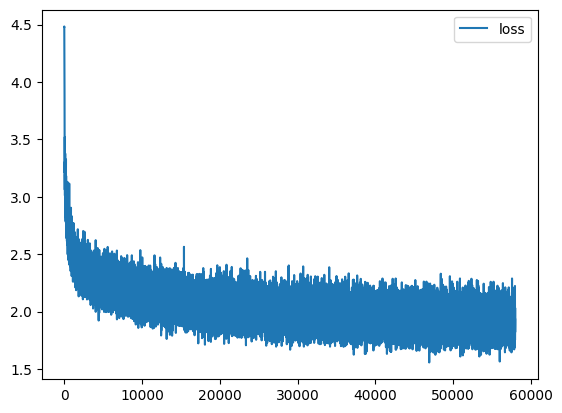

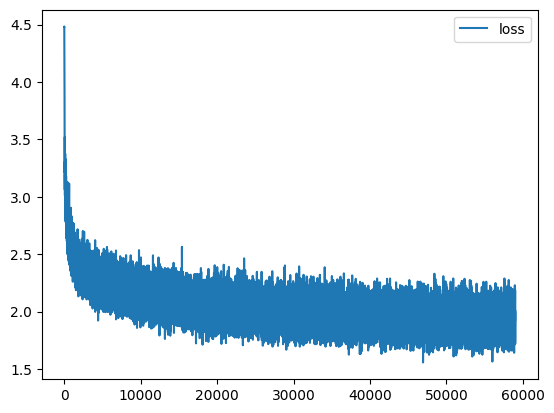

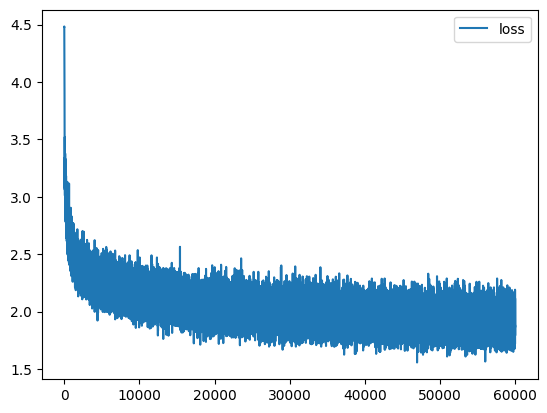

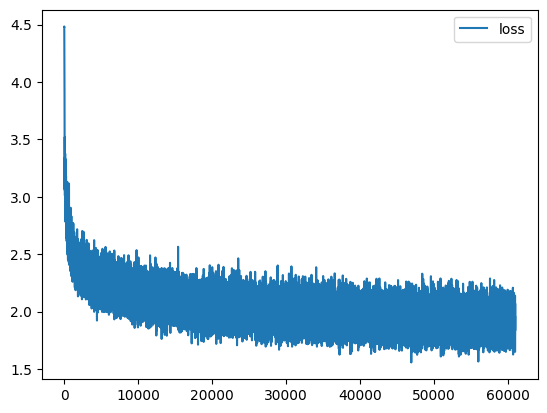

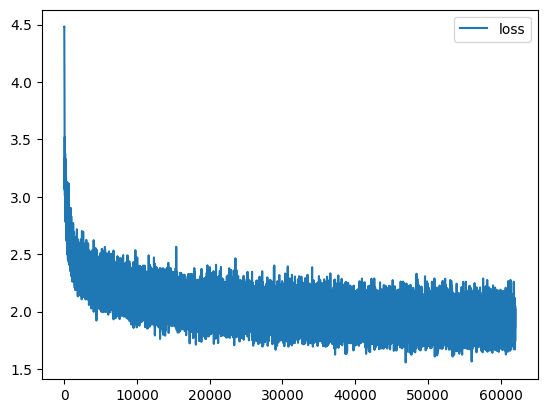

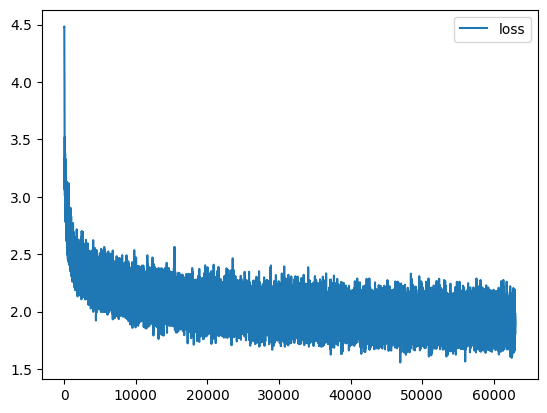

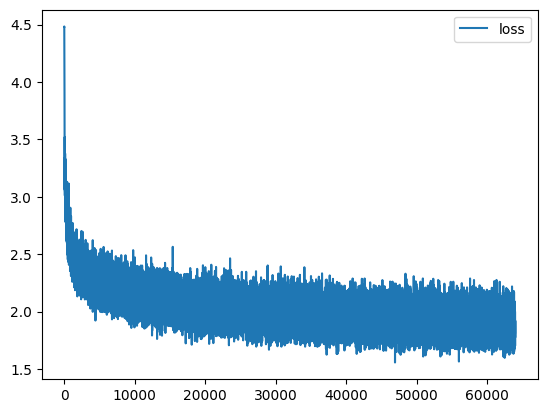

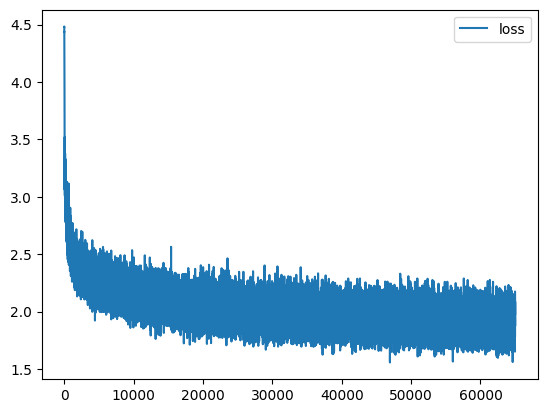

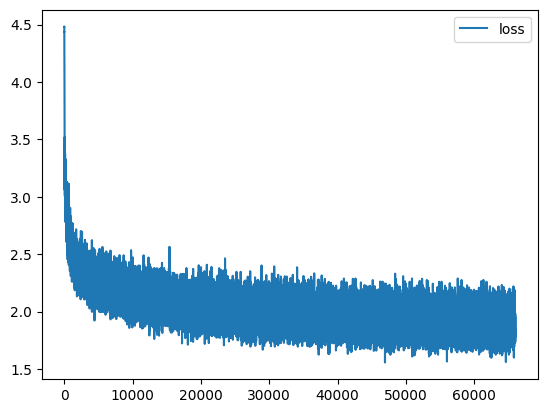

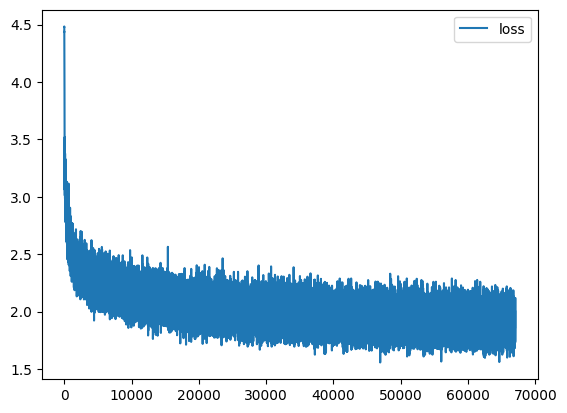

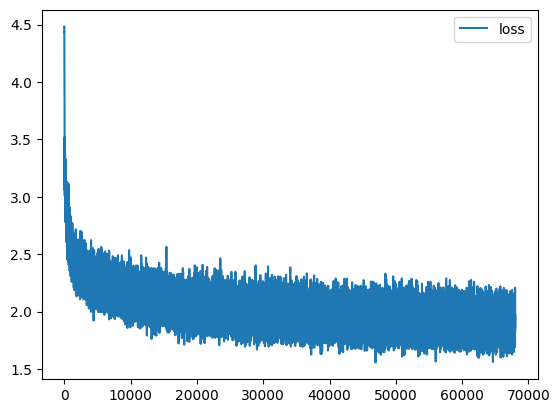

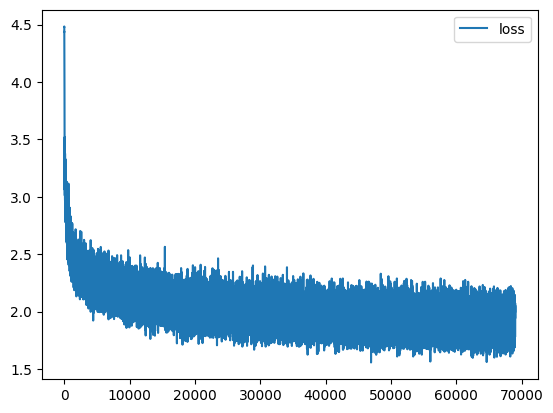

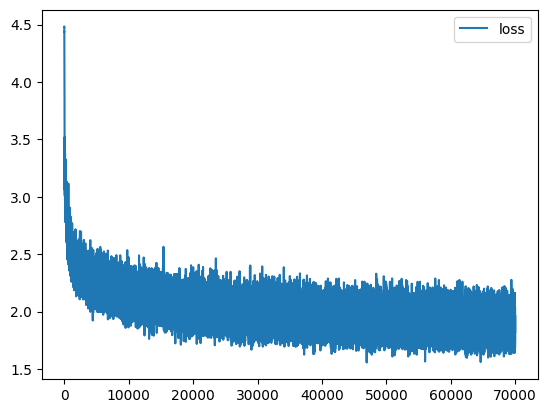

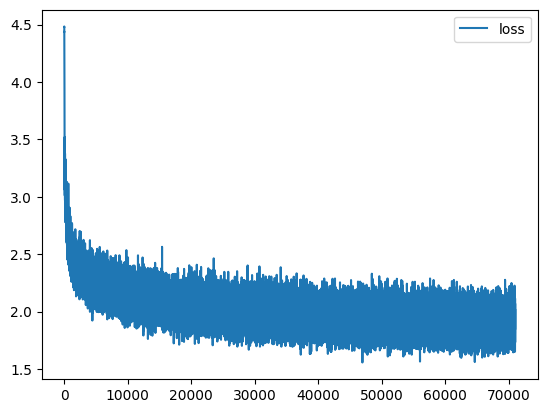

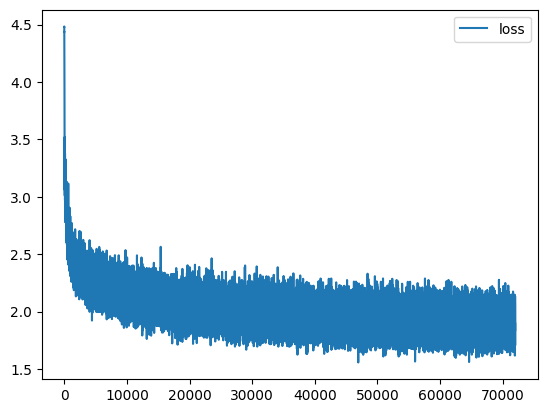

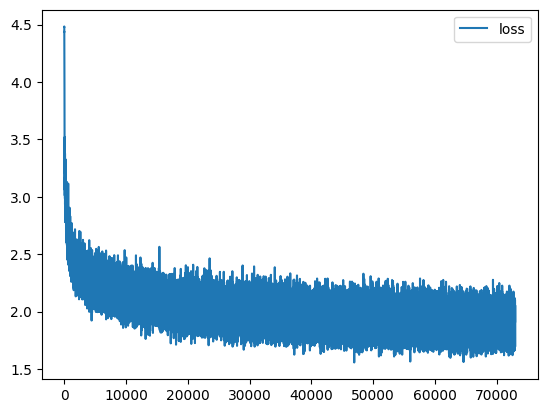

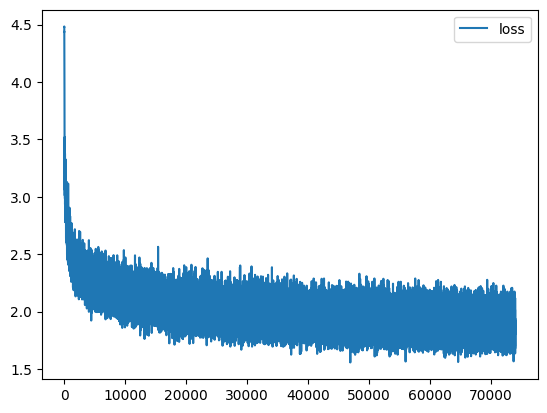

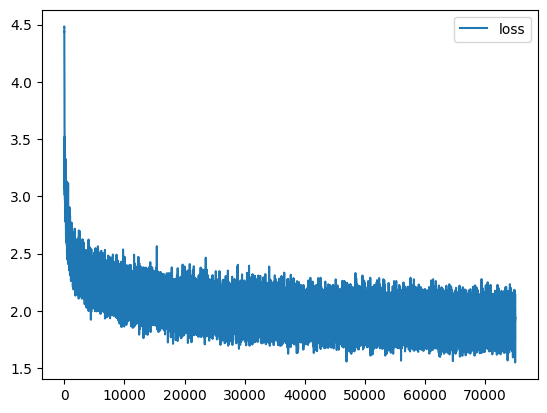

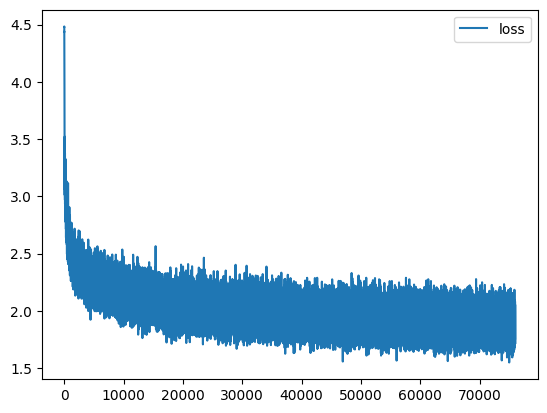

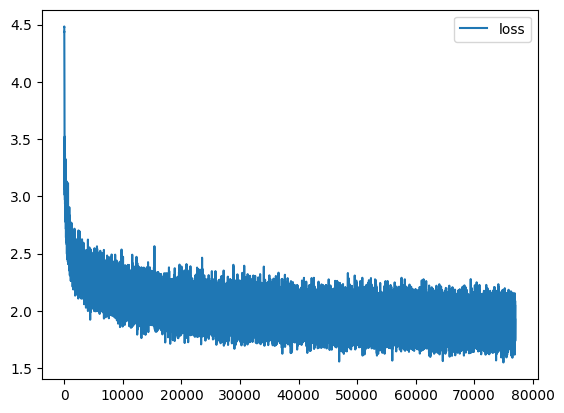

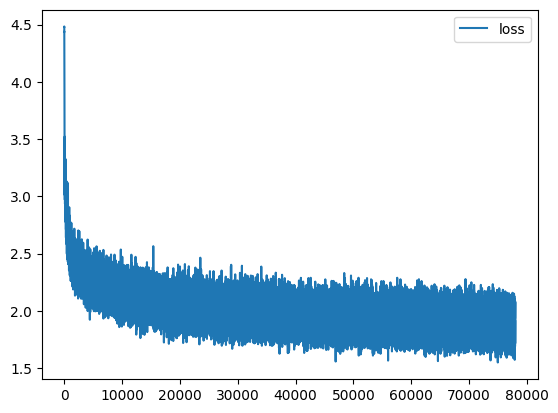

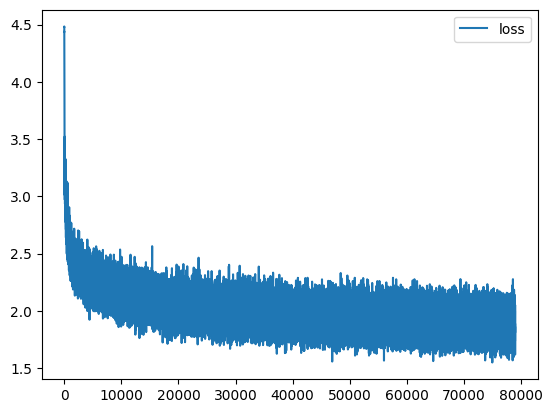

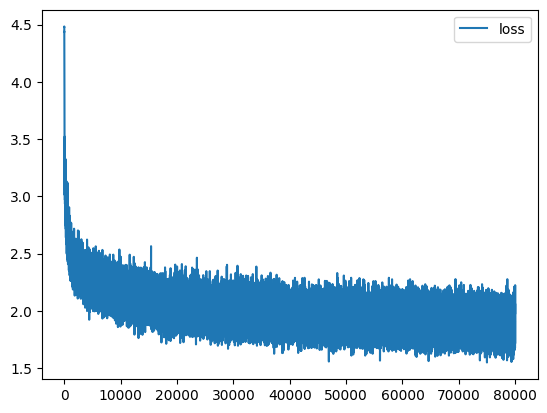

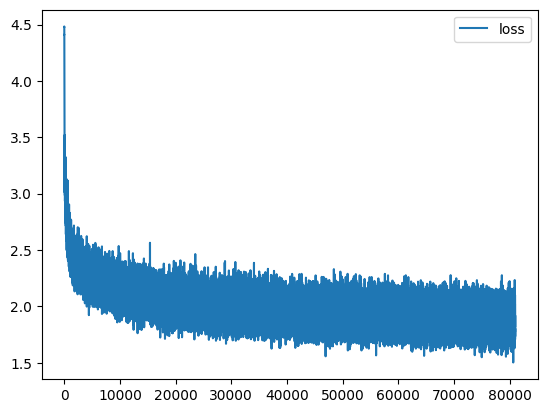

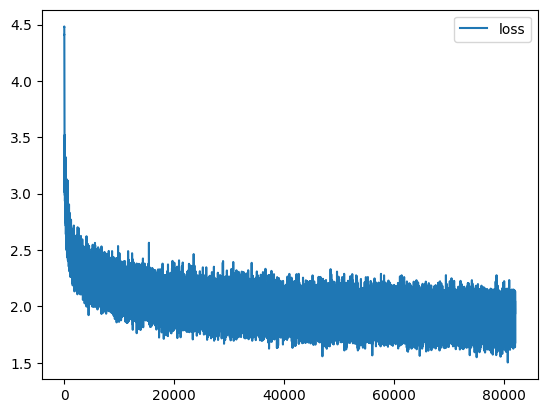

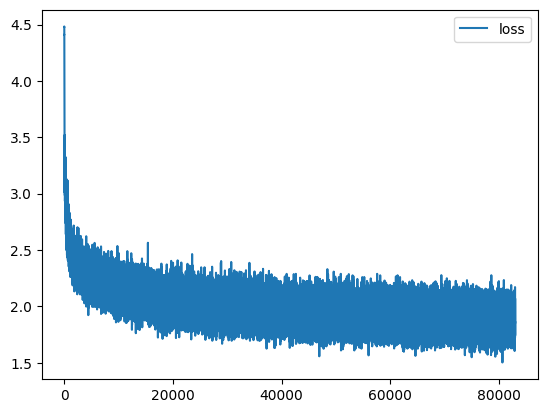

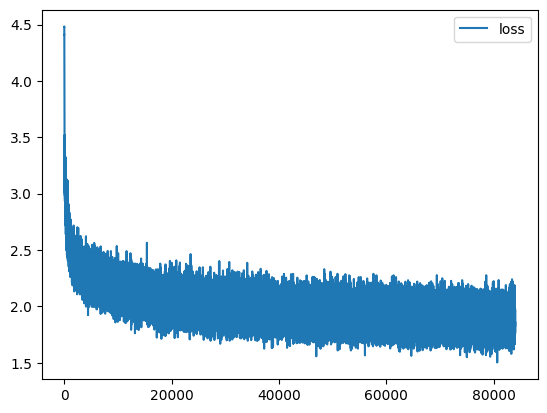

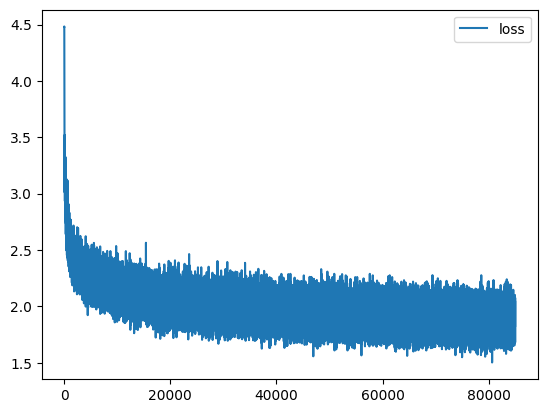

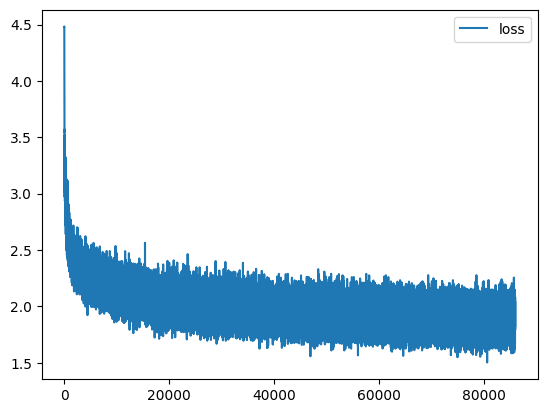

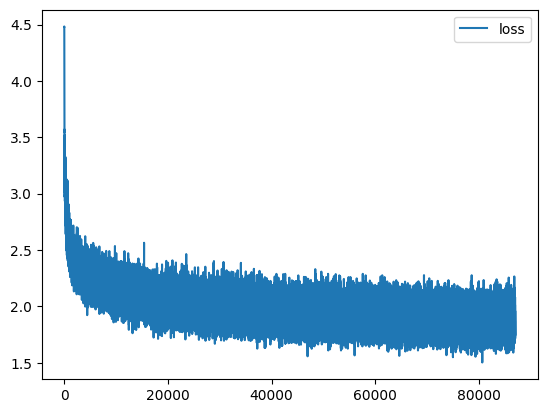

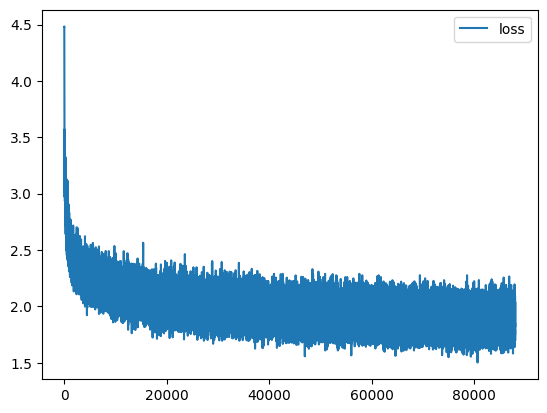

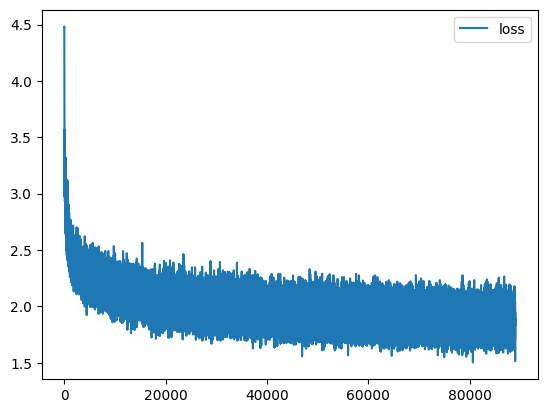

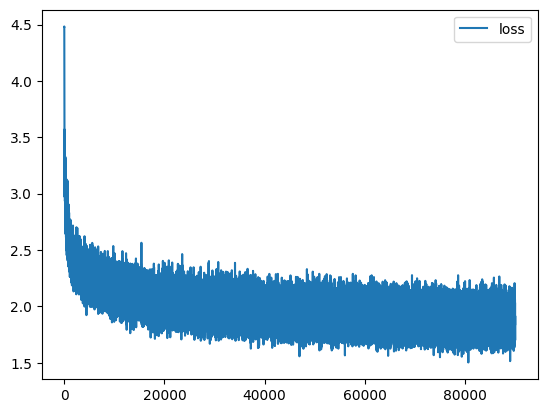

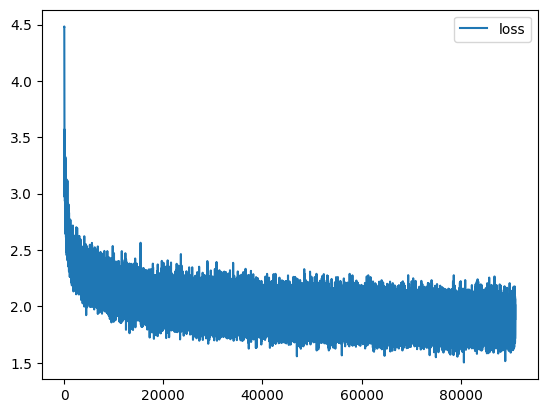

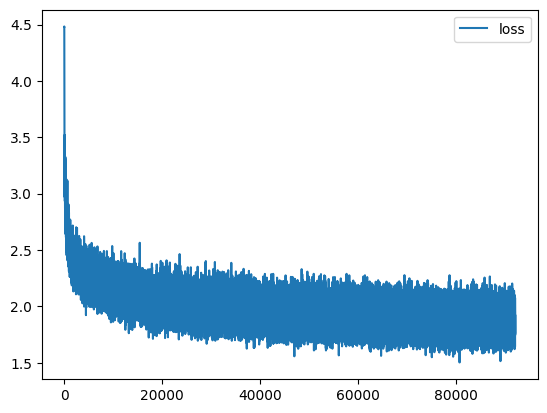

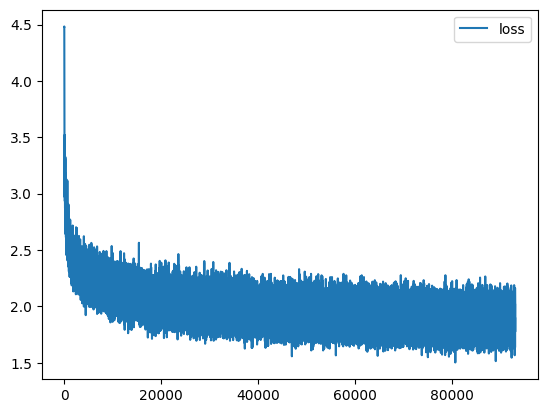

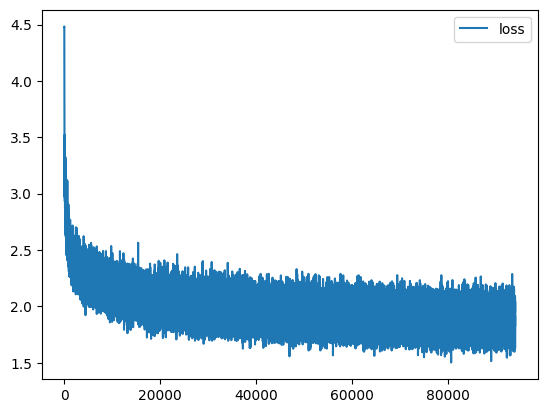

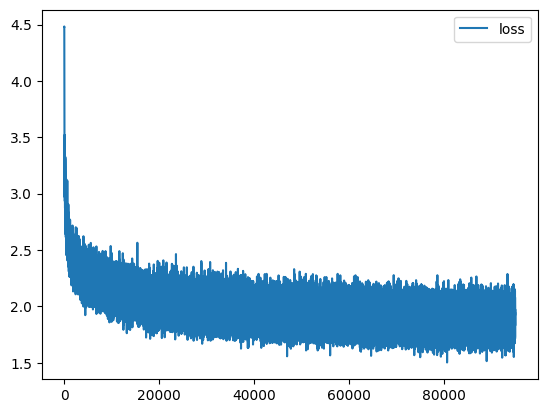

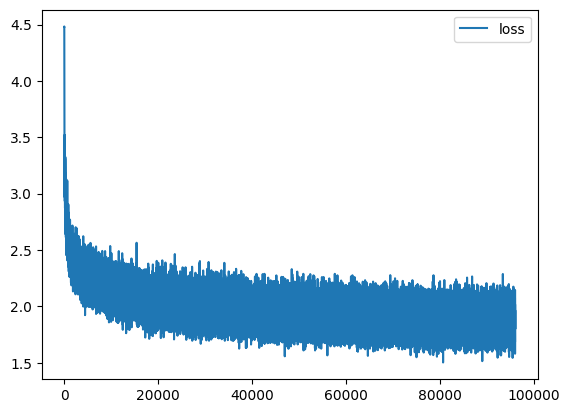

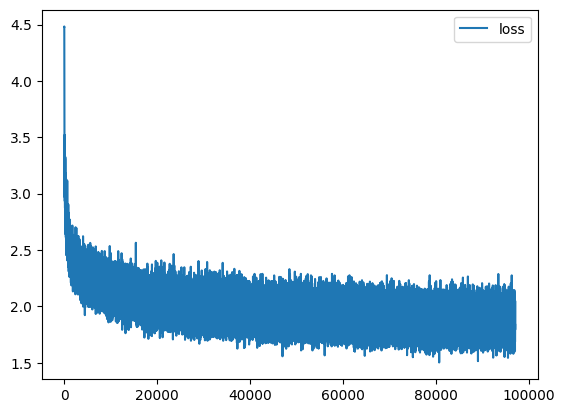

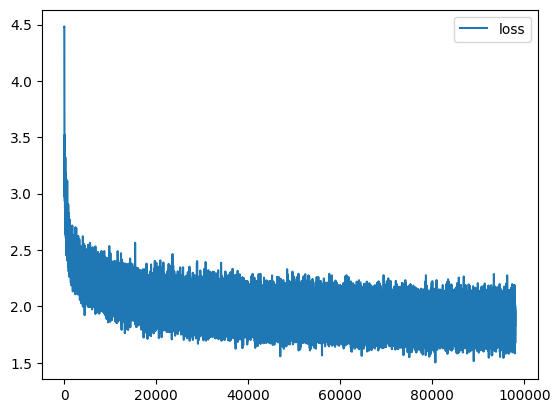

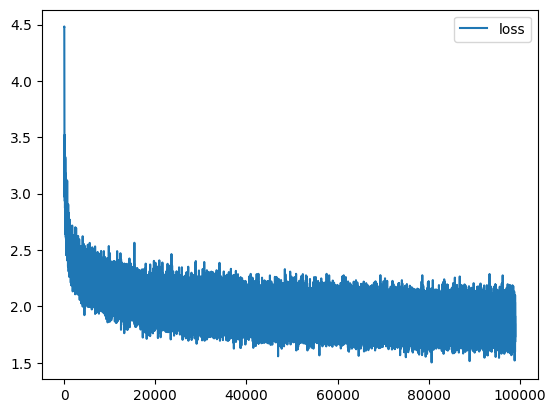

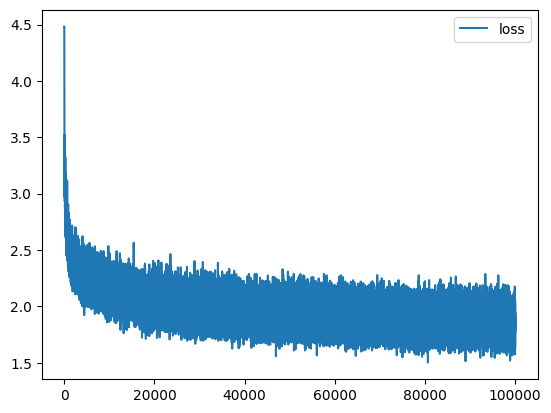

[4.478702545166016,
 4.482807159423828,
 4.46354866027832,
 4.460810661315918,
 4.447516918182373,
 4.433578014373779,
 4.437978744506836,
 4.4264960289001465,
 4.425651550292969,
 4.409611701965332,
 4.415628433227539,
 4.410890579223633,
 4.381701946258545,
 4.381900787353516,
 4.3875579833984375,
 4.356985092163086,
 4.349483966827393,
 4.350918769836426,
 4.332523345947266,
 4.343028545379639,
 4.319056987762451,
 4.300669193267822,
 4.278294086456299,
 4.243575096130371,
 4.242159366607666,
 4.214878082275391,
 4.191932201385498,
 4.164831161499023,
 4.14180326461792,
 4.125093936920166,
 4.082733154296875,
 4.032169818878174,
 4.0521745681762695,
 3.955928325653076,
 3.940349817276001,
 3.8845207691192627,
 3.7649543285369873,
 3.784496784210205,
 3.724379539489746,
 3.691239356994629,
 3.612901449203491,
 3.598881721496582,
 3.5409345626831055,
 3.5009520053863525,
 3.5696051120758057,
 3.486905097961426,
 3.4287726879119873,
 3.4095847606658936,
 3.3597335815429688,
 3.45229148

In [30]:
# Обучение модели Vanilla RNN
vanilla_rnn = VanillaRNN(len(token_to_idx), embedding_dim=18, hidden_dim=64)
train_model(vanilla_rnn, to_matrix(text_On), token_to_idx)

# Обучение модели LSTM
lstm_model = LSTMModel(len(token_to_idx), embedding_dim=18, hidden_dim=64)
train_model(lstm_model, to_matrix(text_On), token_to_idx)

In [25]:
import torch
import torch.nn.functional as F

In [31]:
def generate_text(model, start_words, vocab=token_to_idx, max_length=256, temperature=0.5):
    # Фильтруем словарь от служебных символов
    filtered_vocab = {word: idx for word, idx in vocab.items() if word not in ['<', '_', '>']}
    filtered_vocab_inverse = {idx: word for word, idx in filtered_vocab.items()}

    # Преобразуем начальные слова в индексы
    start_idx = [filtered_vocab.get(word, 80) for word in start_words]  # Используем -1 как индекст по умолчанию
    start_idx = [idx for idx in start_idx if idx != -1]  # Убираем невалидные индексы

    if not start_idx:
        raise ValueError("None of the start words found in the vocabulary!")

    input_seq = torch.tensor(start_idx, dtype=torch.int64).unsqueeze(0)
    h_prev = model.initial_state(input_seq.size(0))

    generated_text = start_words.copy()  # Копируем начальные слова для итогового текста

    # Подаем начальные слова в модель
    for i in range(len(start_idx)):
        out, h_prev = model(input_seq[:, i].unsqueeze(0), h_prev)

    # Начинаем генерацию
    for _ in range(max_length - len(start_words)):
        input_last = input_seq[:, -1].unsqueeze(0)  # Убедимся, что размер входа корректный
        out, h_prev = model(input_last, h_prev)
        out = out.squeeze(0)
        # Применяем softmax и выбираем следующее слово с использованием температуры
        p_next = F.softmax(out / temperature, dim=-1).squeeze(0).data.numpy()

        # Обеспечиваем, что p_next соответствует размеру filtered_vocab
        p_filtered = p_next[list(filtered_vocab.values())]  # Сохраняем порядок, соответствующий filtered_vocab
        p_filtered_sum = np.sum(p_filtered)
        # Нормализуем вероятности
        if p_filtered_sum != 0:
            p_filtered = p_filtered / p_filtered_sum
        else:
            p_filtered = np.ones_like(p_filtered) / len(p_filtered)  # Если сумма равна 0, делаем равномерное распределение
        
        # Проверяем, что p_filtered не содержит NaN и сумма вероятностей равна 1
        if np.any(np.isnan(p_filtered)):
            raise ValueError("NaN values encountered in probabilities: {}".format(p_filtered))
        if not np.isclose(p_filtered.sum(), 1.0):
            raise ValueError("Probabilities do not sum to 1: {}".format(p_filtered))

        # Выбираем следующее слово
        next_word_idx = np.random.choice(list(filtered_vocab.values()), p = p_filtered)
        
        # Получаем слово по индексу
        next_word = filtered_vocab_inverse[next_word_idx]
        generated_text.append(next_word)

        # Обновляем последовательность ввода
        next_word_tensor = torch.tensor([[next_word_idx]], dtype=torch.int64)
        input_seq = torch.cat((input_seq, next_word_tensor), dim=1)

    return generated_text

# An example of generated text.
# Генерация текста
start_words = ["мой ", "дядя ", "самых ", "честных ", "правил "]
generated_text_rnn = generate_text(vanilla_rnn, start_words)
generated_text_lstm = generate_text(lstm_model, start_words)

print("Generated text with Vanilla RNN:")
print("".join(generated_text_rnn))

print("\nGenerated text with LSTM:")
print("".join(generated_text_lstm))

Generated text with Vanilla RNN:
мой дядя самых честных правил i»..).,-ницы,,,,..-e!».».e-re.].),,,,,,.,.-говорились,,,,,,,».».».».».».».».ea.,;,,,......:-pras.),..,.-pras,».,».....».».».»..-aute-horac,.-praste-hor.),.....-prettre..),.-aut-s...............iiii.....-гордцаменьецы,,.-preterar,!.......-praste-ha..).

Generated text with LSTM:
мой дядя самых честных правил фтсокой,,,,,:,,:,,:,:,,,,.--ttsaa.-:й»e..-prie..),.!»,на.....»..,,--steur,-rtasa[78..».),,--ste€bcle,,-parez-vous,..:,-pr.»»щя,-нбовалась,,...........»....),,,,,,-pasl...»..!».)».],,-щемябельяных,,.......)..,)s..)a»;--sяsсьетсяче,.......».,,-sttek:-pa


In [16]:
import torch
import torch.nn.functional as F
import numpy as np

def generate_text(model, start_chars, char_to_idx, max_length=256, temperature=1.0):
    # Фильтруем словарь от служебных символов
    filtered_vocab = {char: idx for char, idx in char_to_idx.items() if char not in ['<SOS>', '<EOS>', '<PAD>']}
    filtered_vocab_inverse = {idx: char for char, idx in filtered_vocab.items()}

    # Преобразуем начальные символы в индексы
    start_idx = [filtered_vocab.get(char, char_to_idx['<PAD>']) for char in start_chars]  # Используем <PAD> как индекс по умолчанию
    start_idx = [idx for idx in start_idx if idx != char_to_idx['<PAD>']]  # Убираем невалидные индексы

    if not start_idx:
        raise ValueError("None of the start characters found in the vocabulary!")

    input_seq = torch.tensor(start_idx, dtype=torch.int64).unsqueeze(0)
    h_prev = model.initial_state(input_seq.size(0))

    generated_text = start_chars.copy()  # Копируем начальные символы для итогового текста

    # Подаем начальные символы в модель
    for i in range(len(start_idx)):
        out, h_prev = model(input_seq[:, i].unsqueeze(0), h_prev)

    # Начинаем генерацию
    for _ in range(max_length - len(start_chars)):
        input_last = input_seq[:, -1].unsqueeze(0)  # Убедимся, что размер входа корректный
        out, h_prev = model(input_last, h_prev)
        out = out.squeeze(0)
        # Применяем softmax и выбираем следующий символ с использованием температуры
        p_next = F.softmax(out / temperature, dim=-1).squeeze(0).data.numpy()

        # Обеспечиваем, что p_next соответствует размеру filtered_vocab
        p_filtered = p_next[list(filtered_vocab.values())]  # Сохраняем порядок, соответствующий filtered_vocab
        p_filtered_sum = np.sum(p_filtered)

        # Нормализуем вероятности
        if p_filtered_sum != 0:
            p_filtered = p_filtered / p_filtered_sum
        else:
            p_filtered = np.ones_like(p_filtered) / len(p_filtered)  # Если сумма равна 0, делаем равномерное распределение

        # Проверяем, что p_filtered не содержит NaN и сумма вероятностей равна 1
        if np.any(np.isnan(p_filtered)):
            raise ValueError("NaN values encountered in probabilities: {}".format(p_filtered))
        if not np.isclose(p_filtered.sum(), 1.0):
            raise ValueError("Probabilities do not sum to 1: {}".format(p_filtered))

        # Выбираем следующий символ
        next_char_idx = np.random.choice(list(filtered_vocab.values()), p=p_filtered)

        # Получаем символ по индексу
        next_char = filtered_vocab_inverse[next_char_idx]
        generated_text.append(next_char)

        # Обновляем последовательность ввода
        next_char_tensor = torch.tensor([[next_char_idx]], dtype=torch.int64)
        input_seq = torch.cat((input_seq, next_char_tensor), dim=1)

    return generated_text

# Пример использования
start_chars = ['м', 'о', 'й', ' ']
char_to_idx = {'м': 1, 'о': 2, 'й': 3, '<SOS>': 4, '<EOS>': 5, '<PAD>': 6, ' ': 7}  # Пример словаря символов

# Предположим, что vanilla_rnn и lstm_model уже определены и обучены
generated_text_rnn = generate_text(vanilla_rnn, start_chars, char_to_idx)
generated_text_lstm = generate_text(lstm_model, start_chars, char_to_idx)

print("Generated text with Vanilla RNN:")
print("".join(generated_text_rnn))

print("\nGenerated text with LSTM:")
print("".join(generated_text_lstm))


Generated text with Vanilla RNN:
мой омой  оооймо  о йо м мо  ойй йом й ммй  ой  йммомо   ооо о о й ммйоммм моом ойоомймоймо о мммйм   ойойооммм мо йомойй ййммйм  о  о омйойо мм моймоммой  о   йо м ооойомй  о  о ой мй ойоммйо ойомй о о мймйй ойм о  ммом йоомйййй мйо йом йоомо й моомй оймм

Generated text with LSTM:
мой    мойммйймм о йм йо оойо ммймм ой  о оомо ймоймомймо о й ймйо йм мйо мммоо мо оййойммййоой омймо ммммой мй мймо  ом йо ой ймй  йй йоойоойййоой ой о м йййомой мой оо оо й мм  ммоо ммо йоо омоо  мймо о оомйоом мй омо й ом  оо йо омоом   ммо м  мм йймйм 
